In [1]:
from m_star_predictor import (
    LinearRegression, FCNN, fit_model
)

from utility import (
    normalize, real_units, reduce_dataset, compute_rmse, MStarPredictorConfig,
    get_predictions, recover_M_from_dM
)

import torch
import torch.utils.data as Data
from torch.utils.data import random_split
from torch import optim
import numpy as np
import os
import json

import pandas as pd

import matplotlib.pyplot as plt

In [2]:
predictor_name = "predictor_33"
predictor_dir = os.path.join("m_star_predictors", predictor_name)
config_json_path = os.path.join(predictor_dir, "config.json")

with open(config_json_path, "r") as f:
    config_dict = json.load(f)

config = MStarPredictorConfig(**config_dict)

In [3]:
# Ensuring reproducibility
np.random.seed(config.random_state)
torch.manual_seed(config.random_state);
sklear_random_state = config.random_state

In [4]:
fcnn_train_traj = config.train_loss_trajectory
fcnn_test_traj = config.test_loss_trajectory
fcnn_name = ""

Text(0.5, 0, 'Epoch')

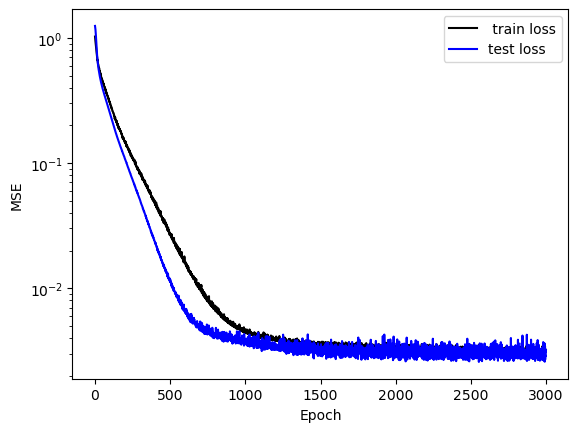

In [5]:
plt.plot(fcnn_train_traj, color="black", label=f" train loss")
plt.plot(fcnn_test_traj, color="blue", label=f"test loss")
plt.gca().set_yscale("log")
plt.legend()
plt.ylabel("MSE")
plt.xlabel("Epoch")

In [6]:
config.dataset_name

'ePBL_paper_expanded_2283_corrected'

In [7]:
data_directory = '../m_star_dataset'

dataset_name = config.dataset_name
validation_dataset_name = config.validation_dataset_name

data = pd.read_csv(os.path.join(data_directory, f"{config.dataset_filename}.csv"))
validation_data = pd.read_csv(os.path.join(data_directory, f"{config.validation_dataset_filename}.csv"))

In [11]:
with open(os.path.join(data_directory, f'{dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_case_dict = json.load(file)

with open(os.path.join(data_directory, f'{validation_dataset_name}_training_set_cases.json'), 'r') as file:
    gotm_validation_case_dict = json.load(file)

In [12]:
X, y, X_val, y_val, fcnn_prediction, fcnn_prediction_val = get_predictions(
    training_data=data,
    validation_data=validation_data,
    config=config
)

In [13]:
config.rmse

2.678496855423873e-07

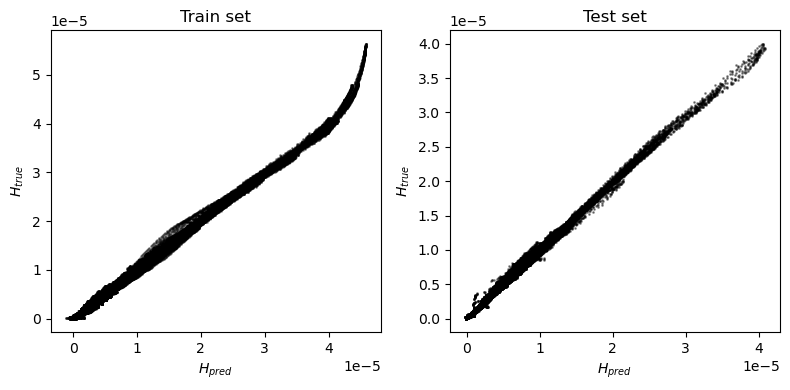

In [14]:
xs, ys = np.linspace(0., 6e-3, 1000), np.linspace(0., 6e-3, 1000)

fig, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].scatter(fcnn_prediction.detach().numpy(), y, color="black", s=1, alpha=.4)
# ax[0].plot(xs, ys, color="red", linestyle="dashed")
ax[0].set_ylabel("$H_{true}$")
ax[0].set_xlabel("$H_{pred}$")
ax[0].set_title("Train set")

ax[1].scatter(fcnn_prediction_val.detach().numpy(), y_val, color="black", s=1, alpha=.4)
# ax[1].plot(xs, ys, color="red", linestyle="dashed")
ax[1].set_ylabel("$H_{true}$")
ax[1].set_xlabel("$H_{pred}$")
ax[1].set_title("Test set")

# fig.suptitle(f"Train and test predictions for {name_1}")

# for a in ax:
    # a.set_xscale("log")
    # a.set_yscale("log")
    # a.set_xlim(0, 1e-5)
    # a.set_ylim(0, 1e-5)

fig.tight_layout()

# plt.savefig(f"inst_M_true_pred_{name_1}.png", dpi=300)

In [28]:
fcnn_pred_diff = fcnn_prediction_val.detach().numpy()[1:] - fcnn_prediction_val.detach().numpy()[:-1]
y_val_diff = y_val[1:] - y_val[:-1]

In [19]:
config.n_time_steps_val

432

In [47]:
config.n_time_steps = 431
config.n_time_steps_val = 431

In [16]:
config.feature_names

['bl_tke',
 'SS_sig_0.00',
 'SS_sig_0.01',
 'SS_sig_0.02',
 'SS_sig_0.03',
 'SS_sig_0.04',
 'SS_sig_0.05',
 'SS_sig_0.06',
 'SS_sig_0.07',
 'SS_sig_0.08',
 'SS_sig_0.09',
 'SS_sig_0.10',
 'SS_sig_0.11',
 'SS_sig_0.12',
 'SS_sig_0.13',
 'SS_sig_0.14',
 'SS_sig_0.15',
 'SS_sig_0.16',
 'SS_sig_0.17',
 'SS_sig_0.18',
 'SS_sig_0.19',
 'SS_sig_0.20',
 'SS_sig_0.21',
 'SS_sig_0.22',
 'SS_sig_0.23',
 'SS_sig_0.24',
 'SS_sig_0.25',
 'SS_sig_0.26',
 'SS_sig_0.27',
 'SS_sig_0.28',
 'SS_sig_0.29',
 'SS_sig_0.30',
 'SS_sig_0.31',
 'SS_sig_0.32',
 'SS_sig_0.33',
 'SS_sig_0.34',
 'SS_sig_0.35',
 'SS_sig_0.36',
 'SS_sig_0.37',
 'SS_sig_0.38',
 'SS_sig_0.39',
 'SS_sig_0.40',
 'SS_sig_0.41',
 'SS_sig_0.42',
 'SS_sig_0.43',
 'SS_sig_0.44',
 'SS_sig_0.45',
 'SS_sig_0.46',
 'SS_sig_0.47',
 'SS_sig_0.48',
 'SS_sig_0.49',
 'SS_sig_0.50',
 'SS_sig_0.51',
 'SS_sig_0.52',
 'SS_sig_0.53',
 'SS_sig_0.54',
 'SS_sig_0.55',
 'SS_sig_0.56',
 'SS_sig_0.57',
 'SS_sig_0.58',
 'SS_sig_0.59',
 'SS_sig_0.60',
 'SS_sig_0.61

/tmp/ipykernel_151108/3854738150.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(2,1,figsize=(10,6),tight_layout=True,sharex=True)


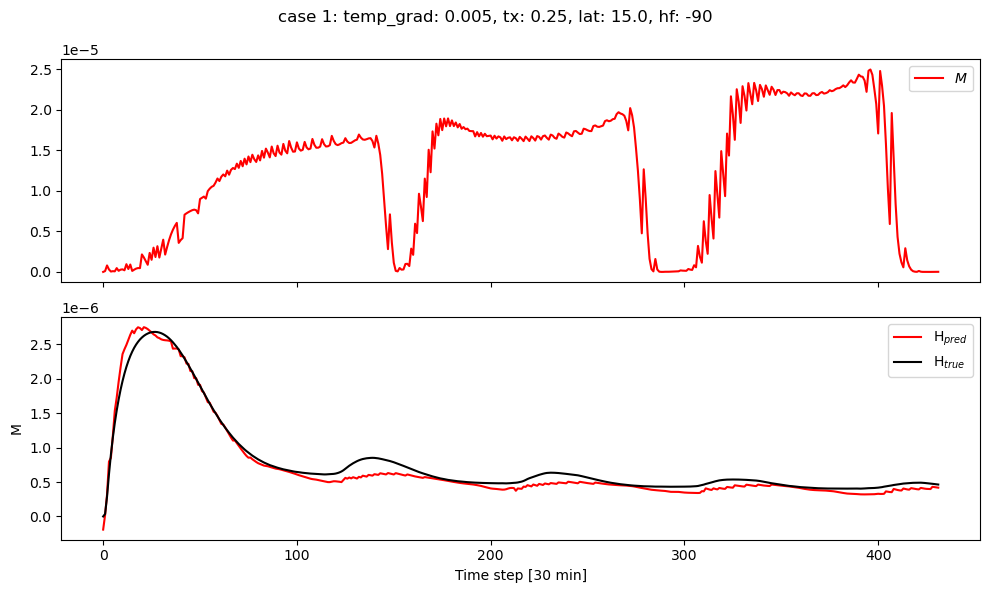

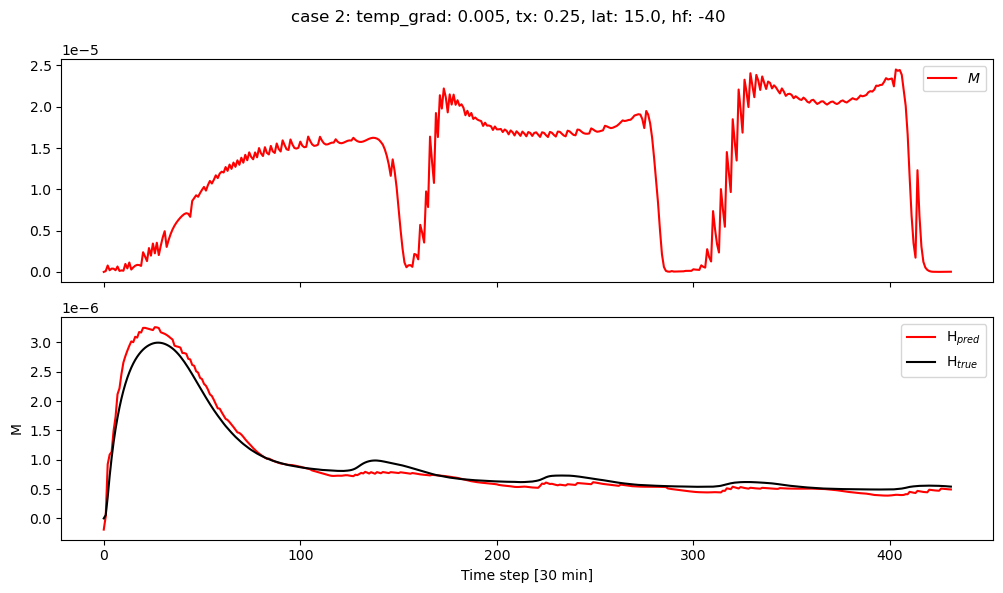

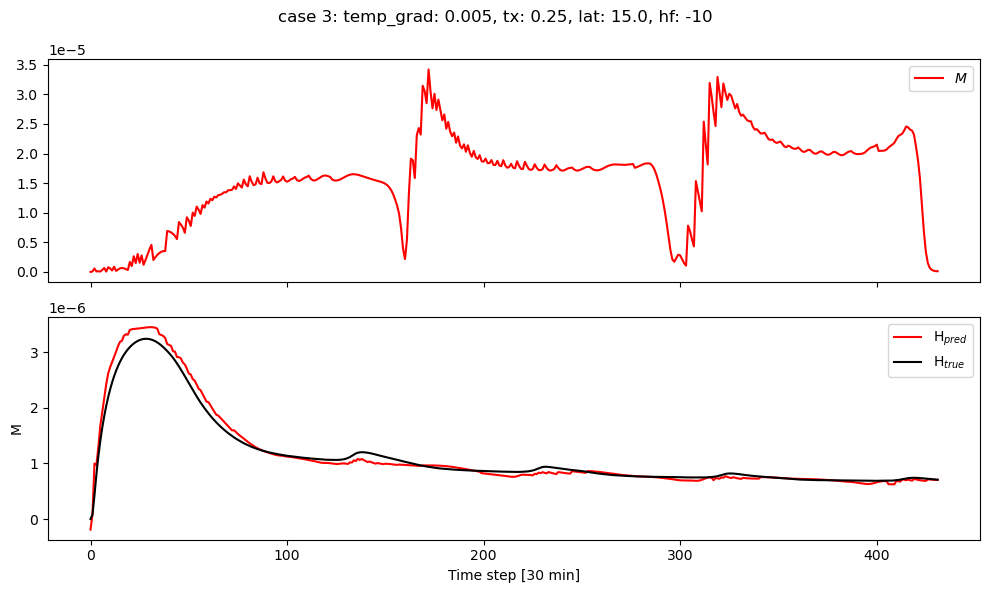

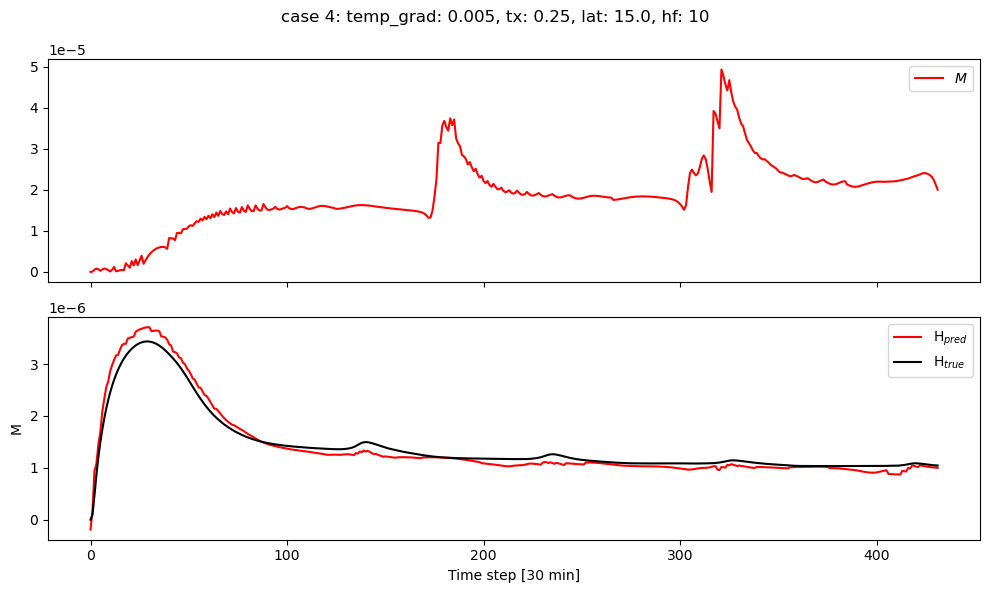

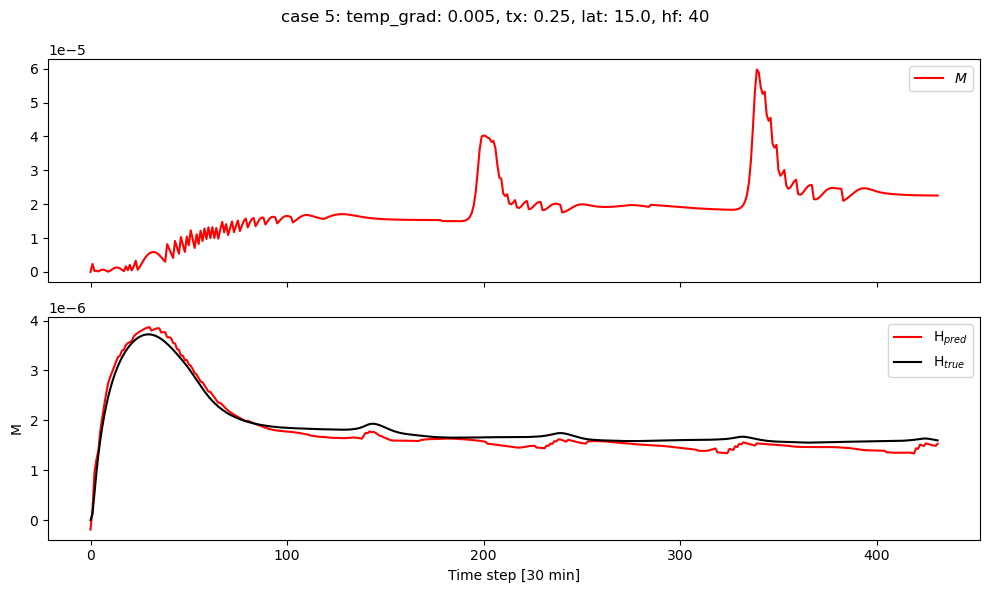

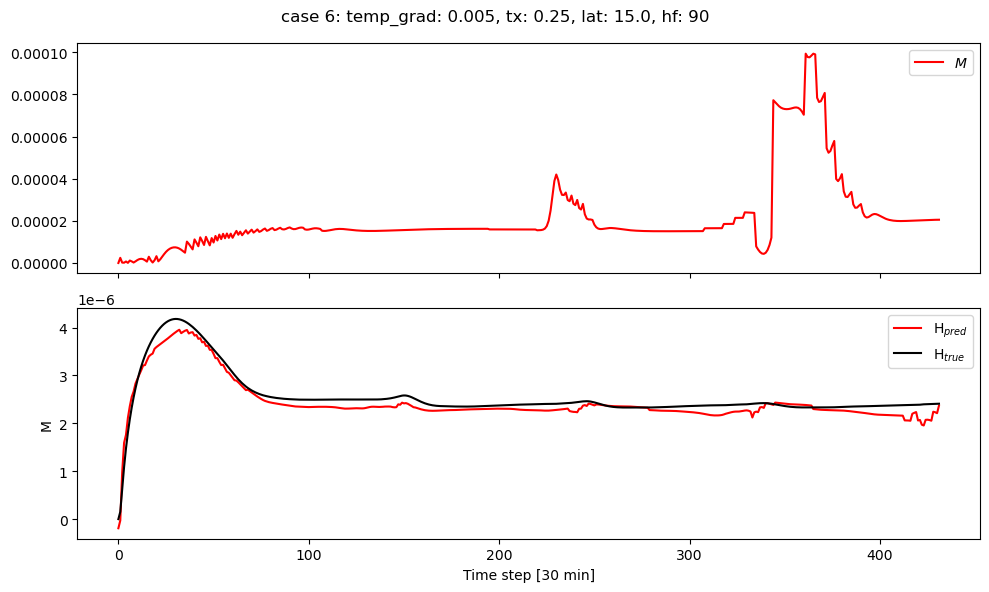

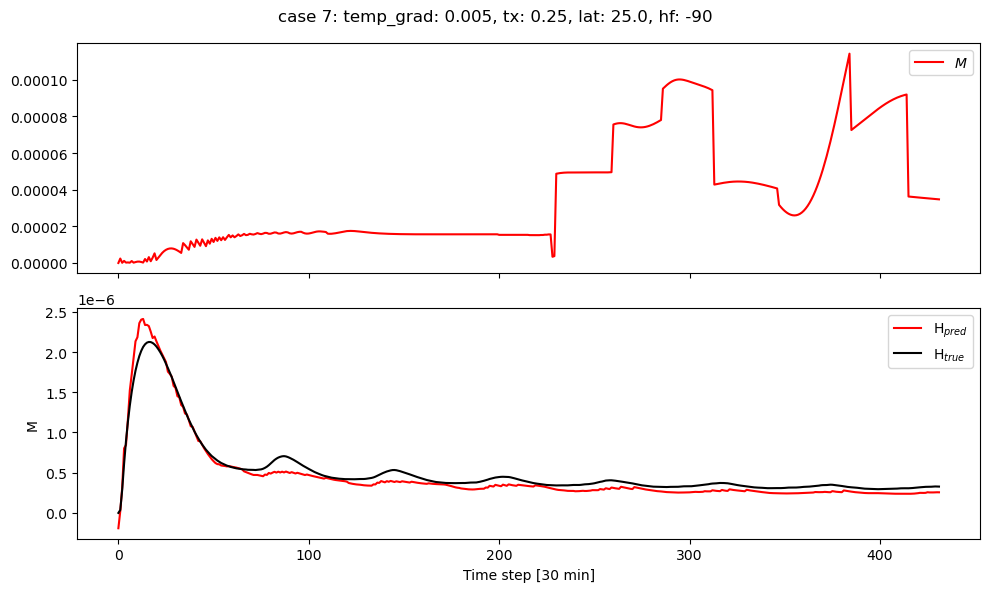

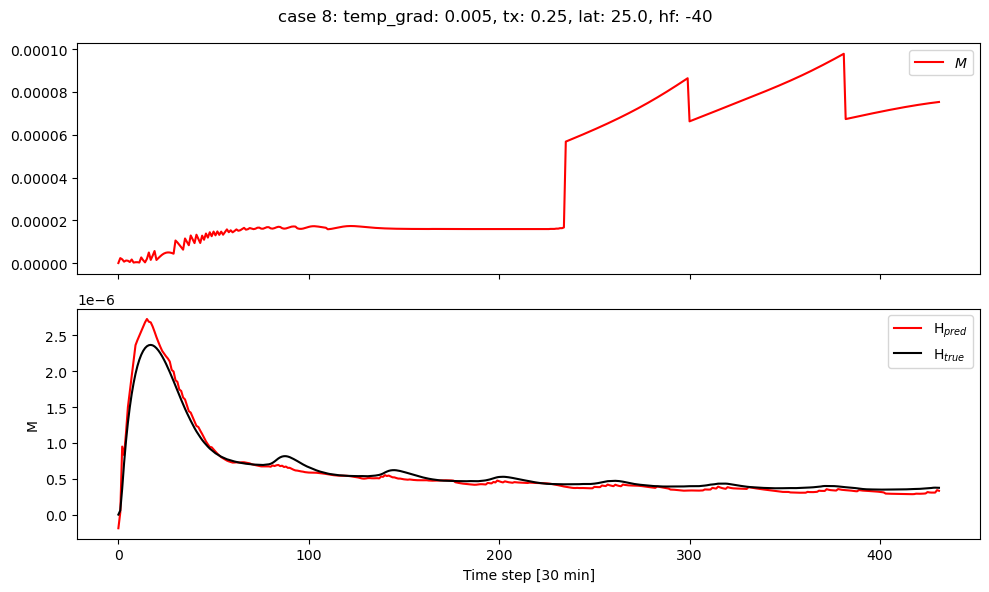

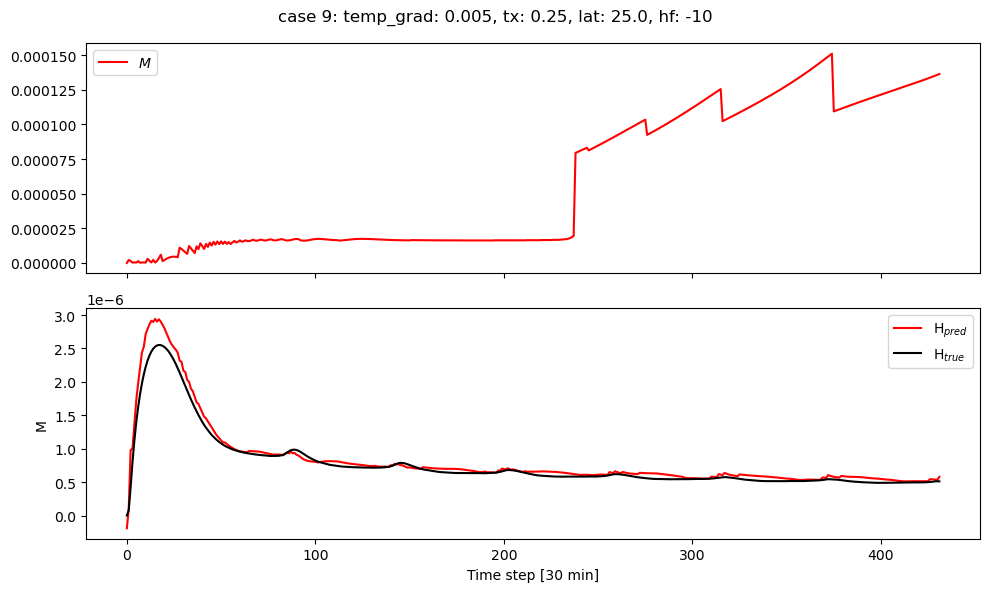

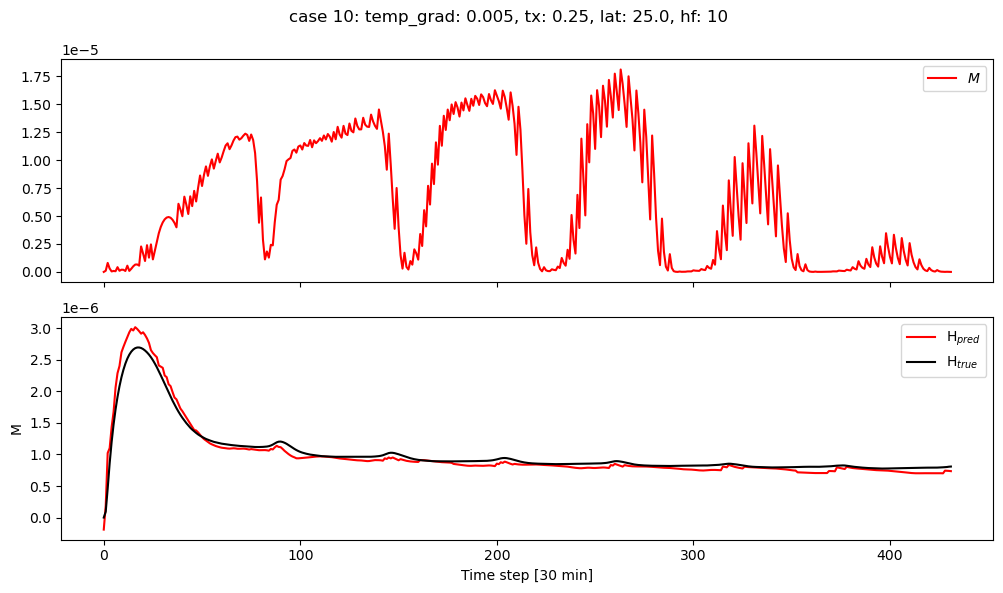

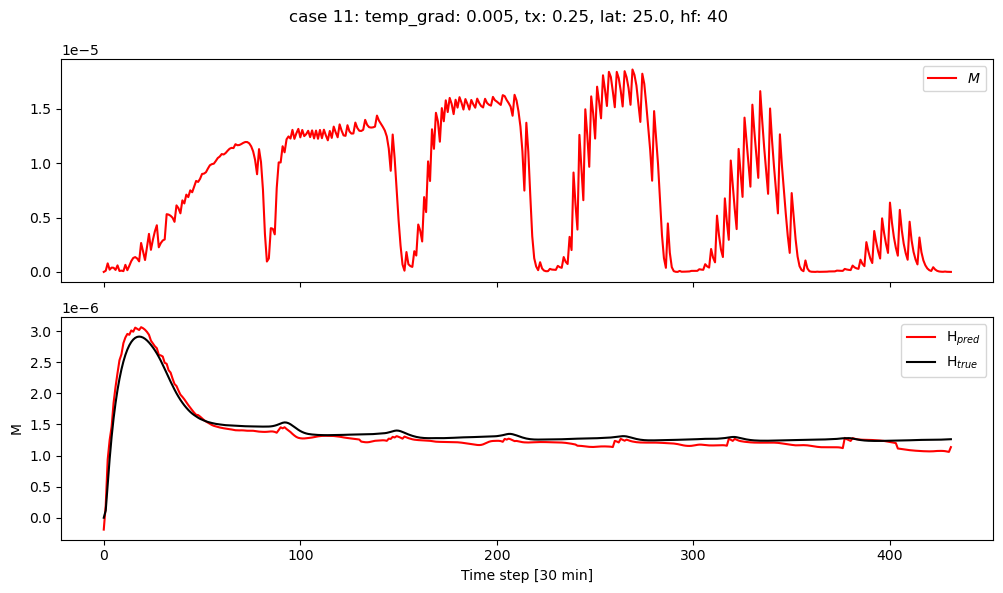

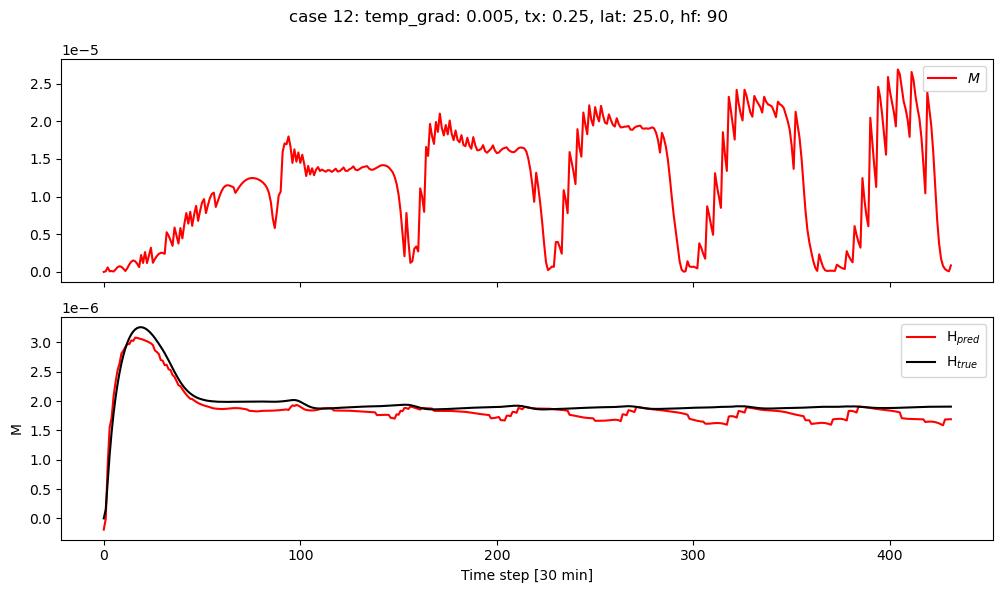

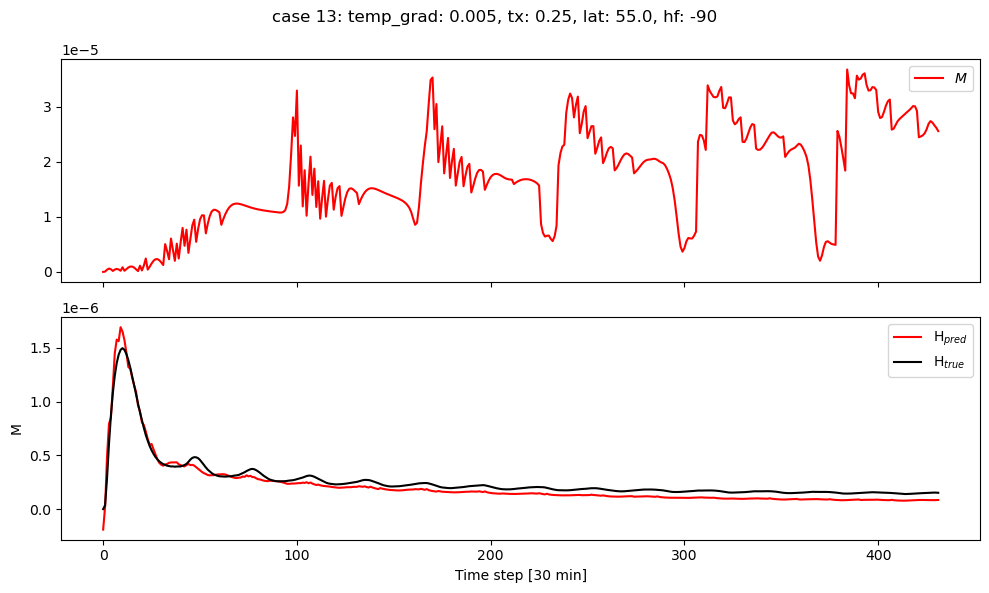

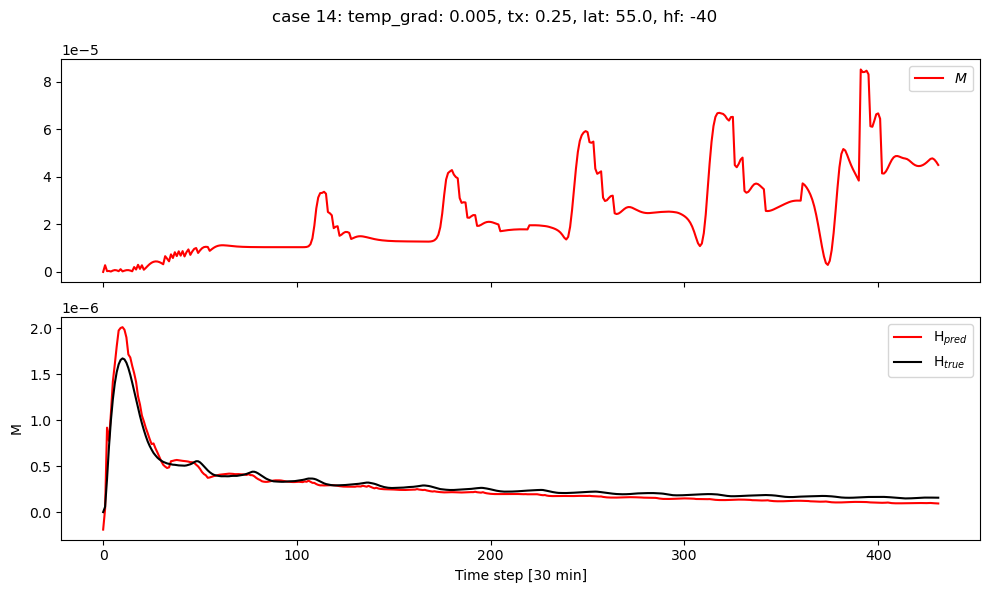

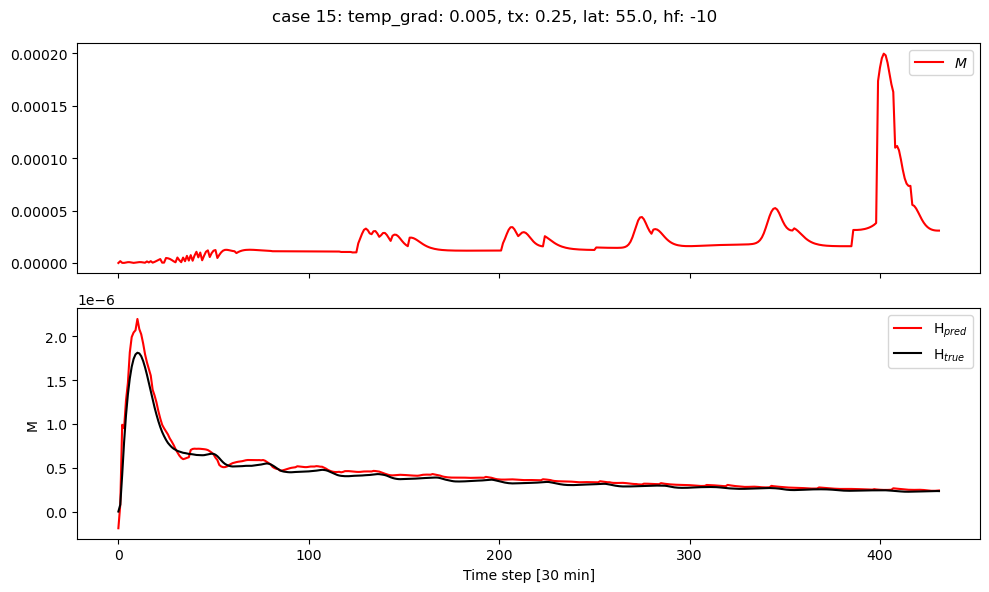

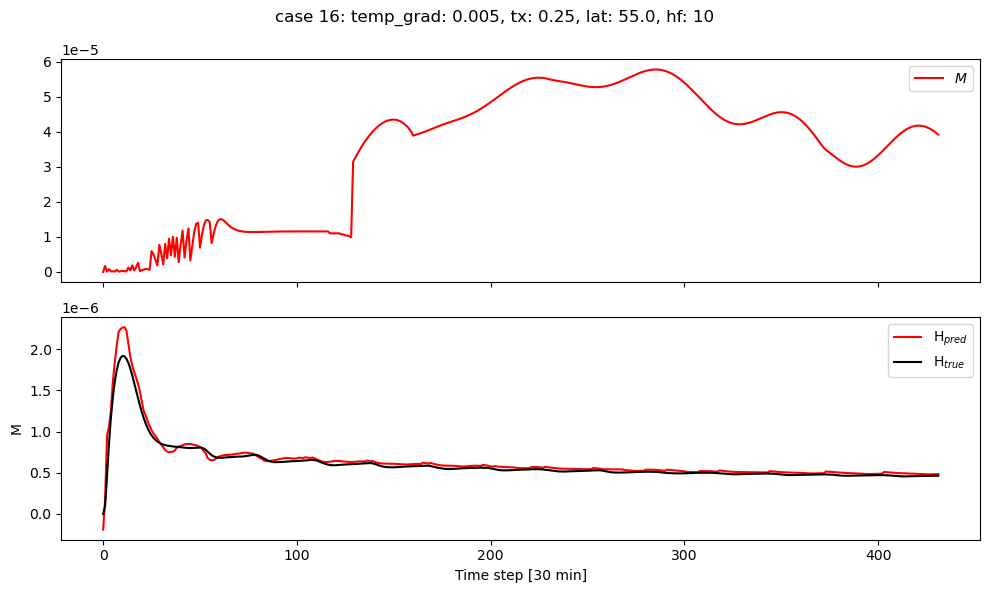

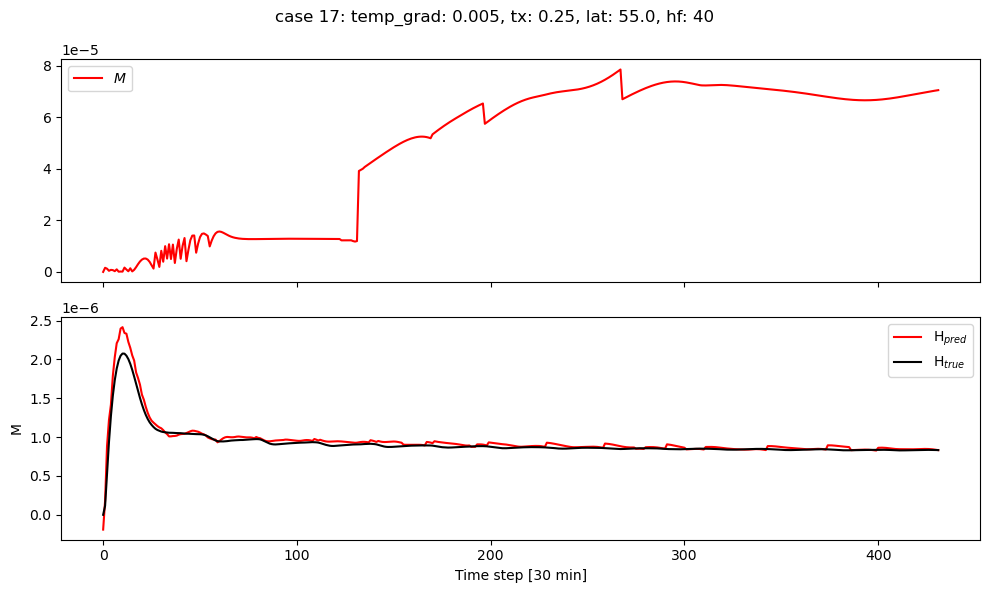

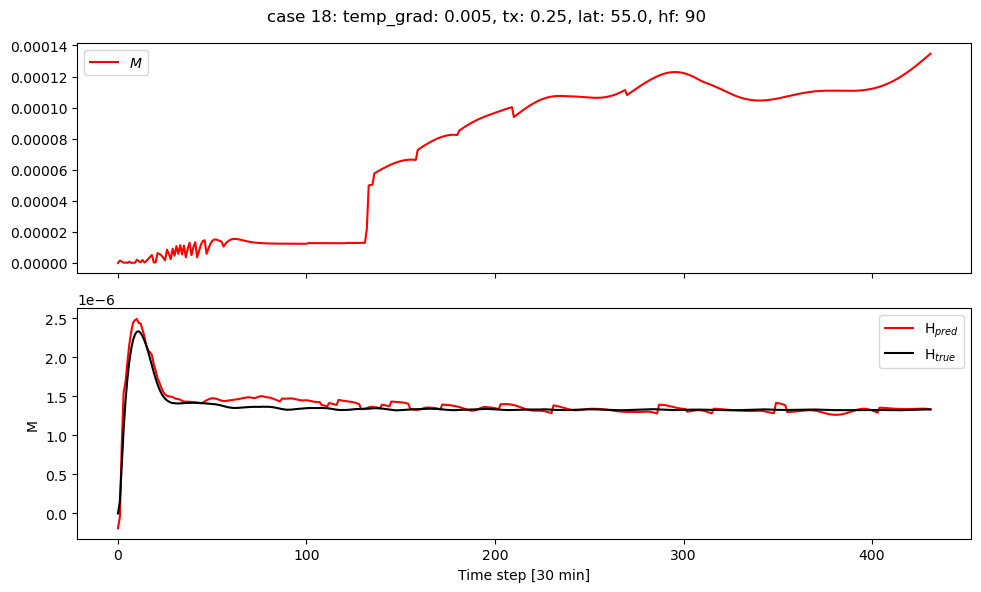

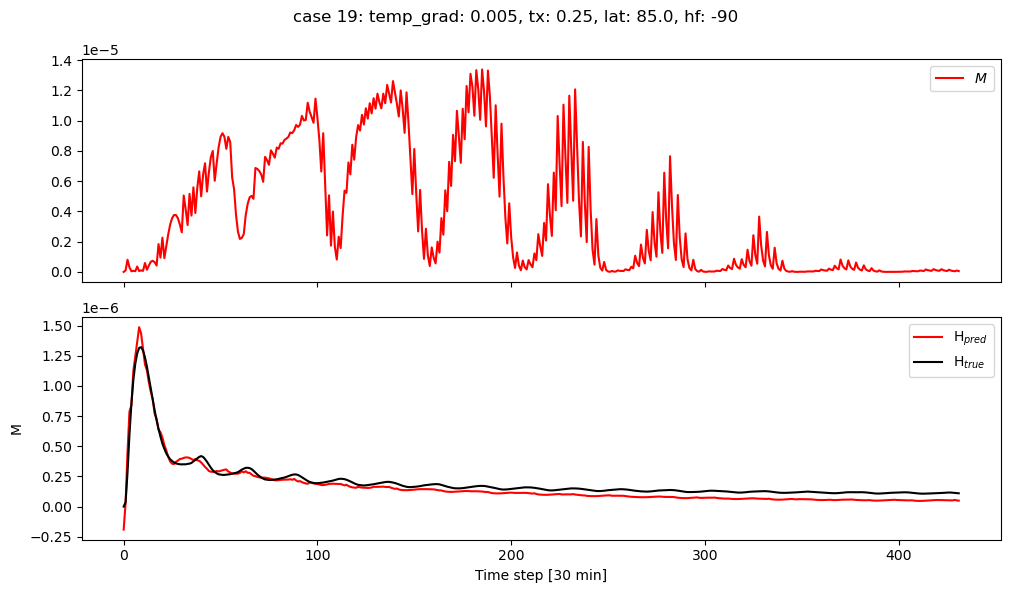

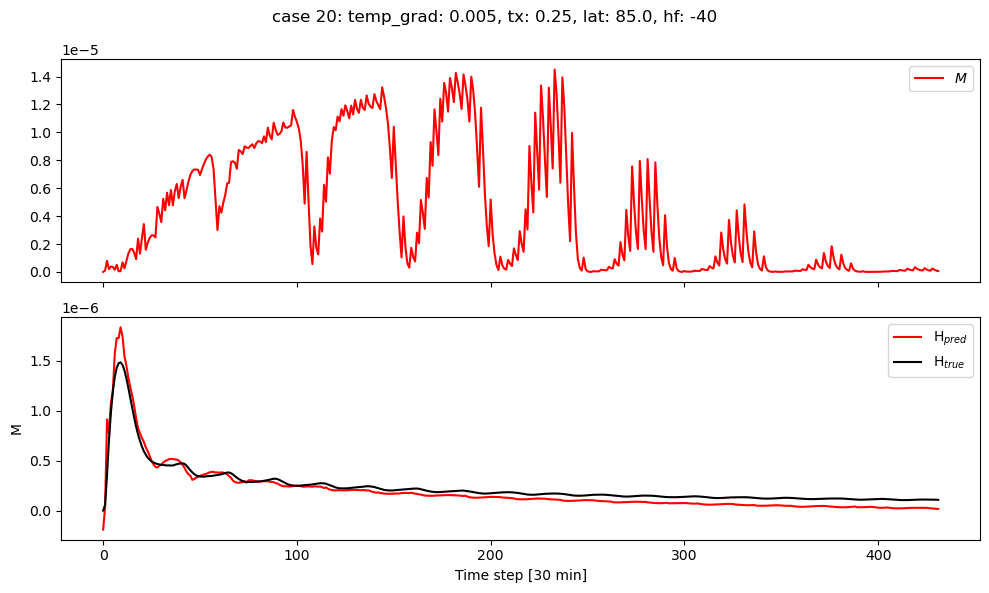

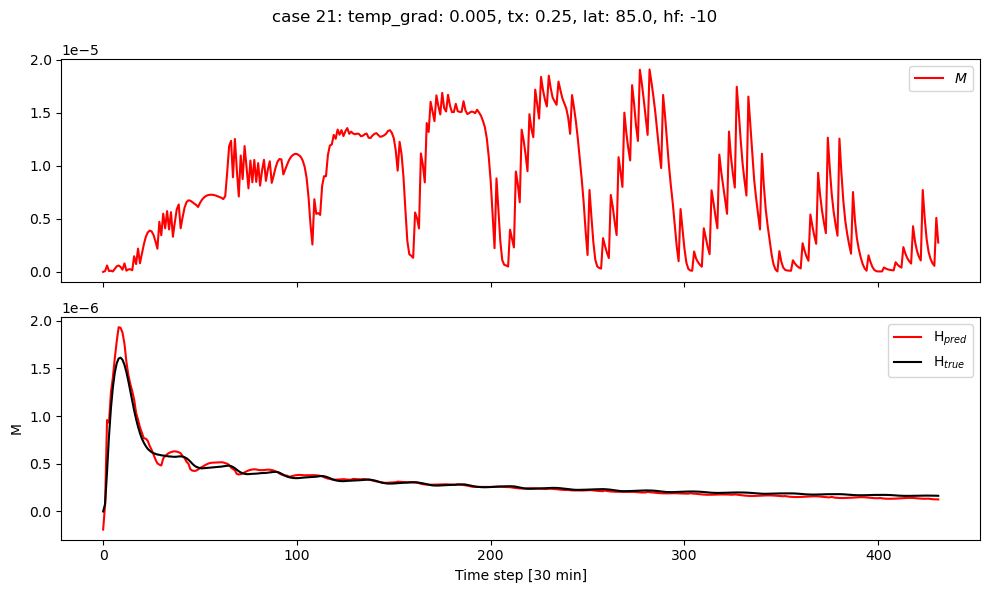

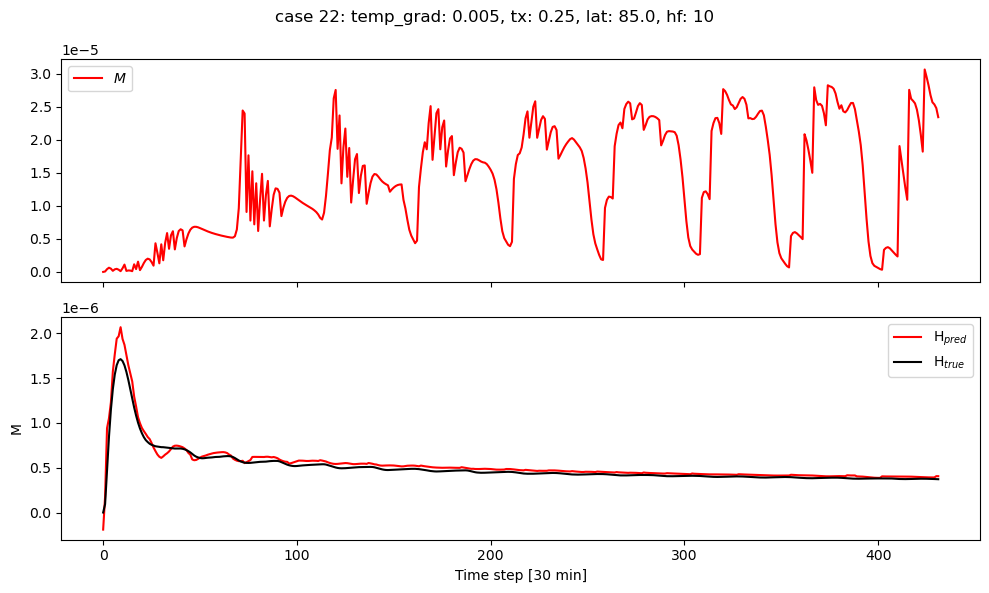

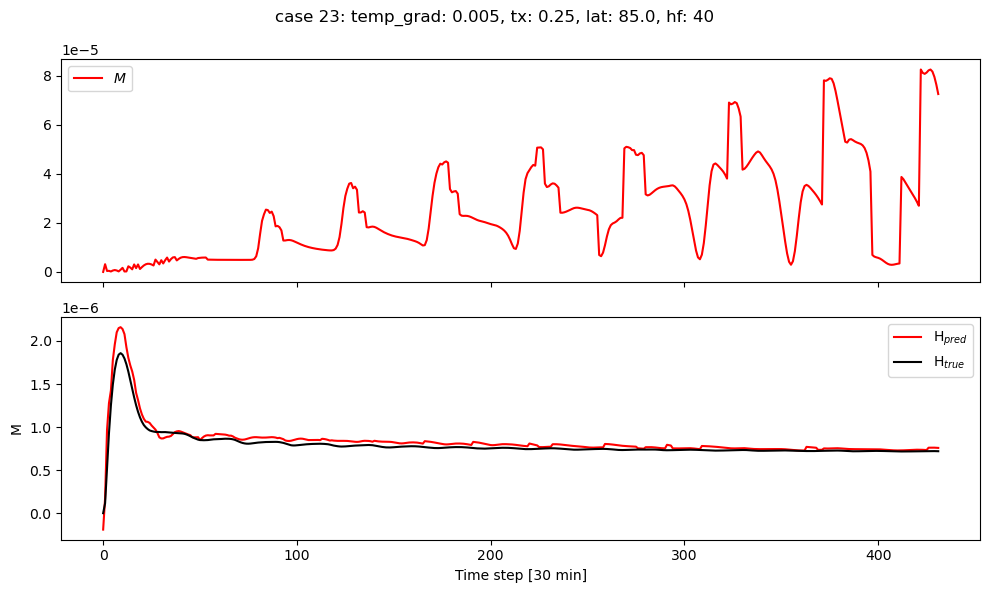

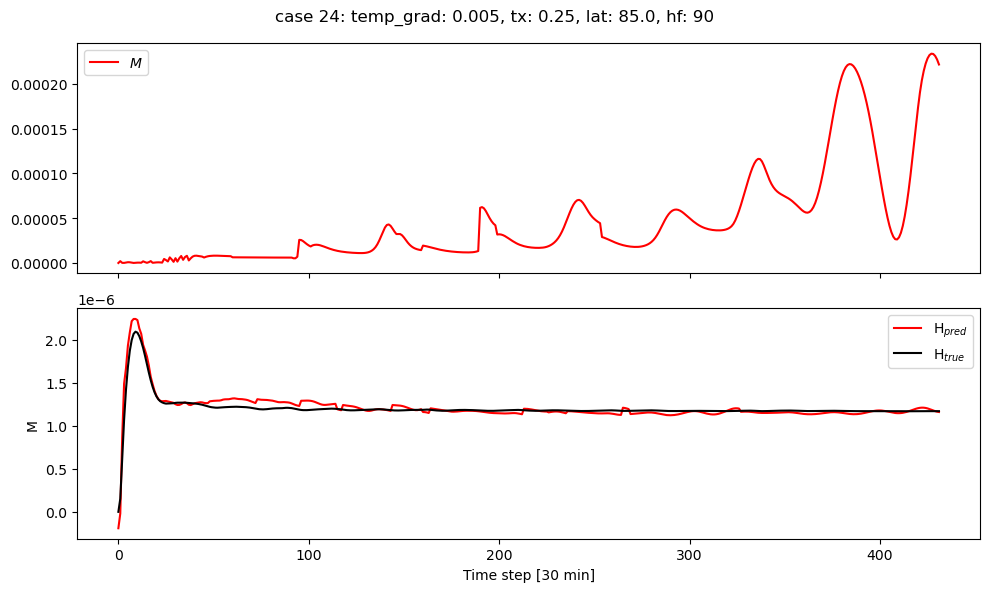

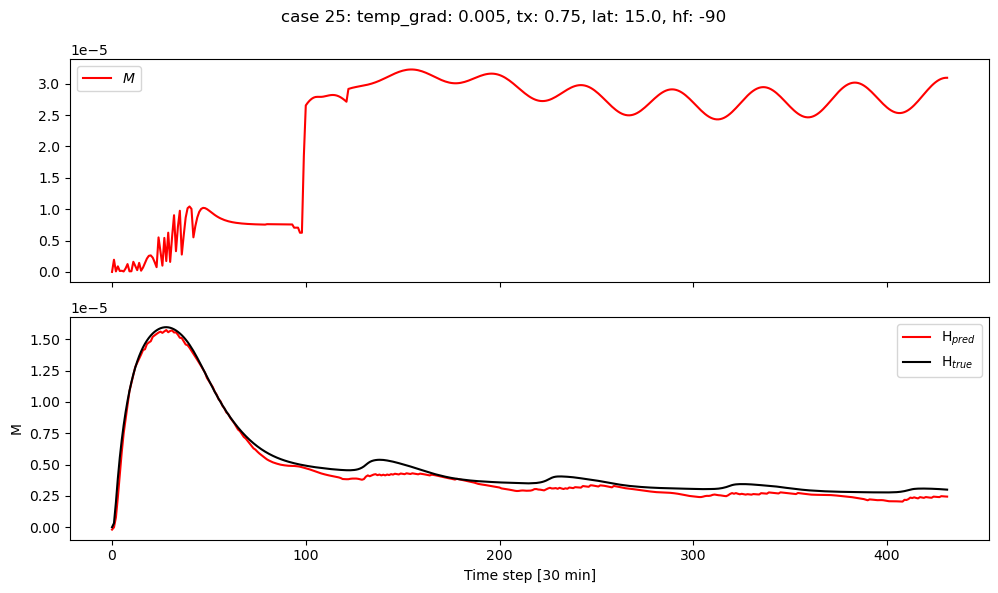

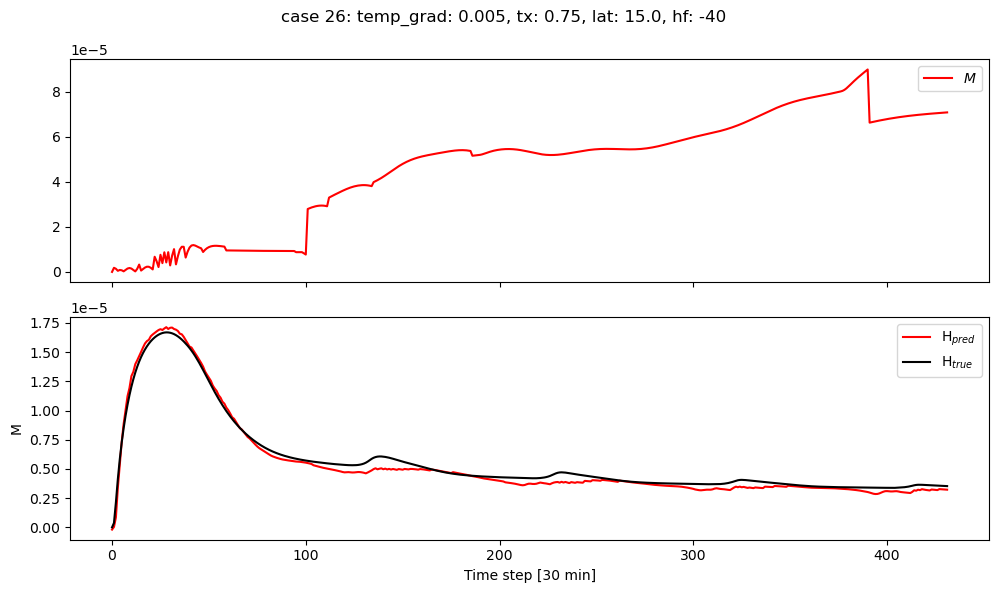

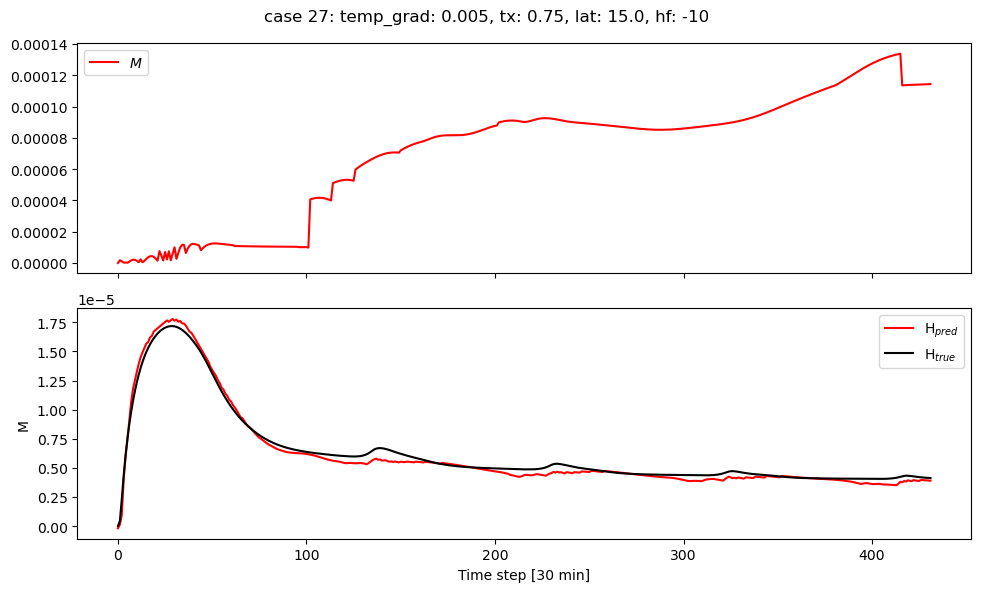

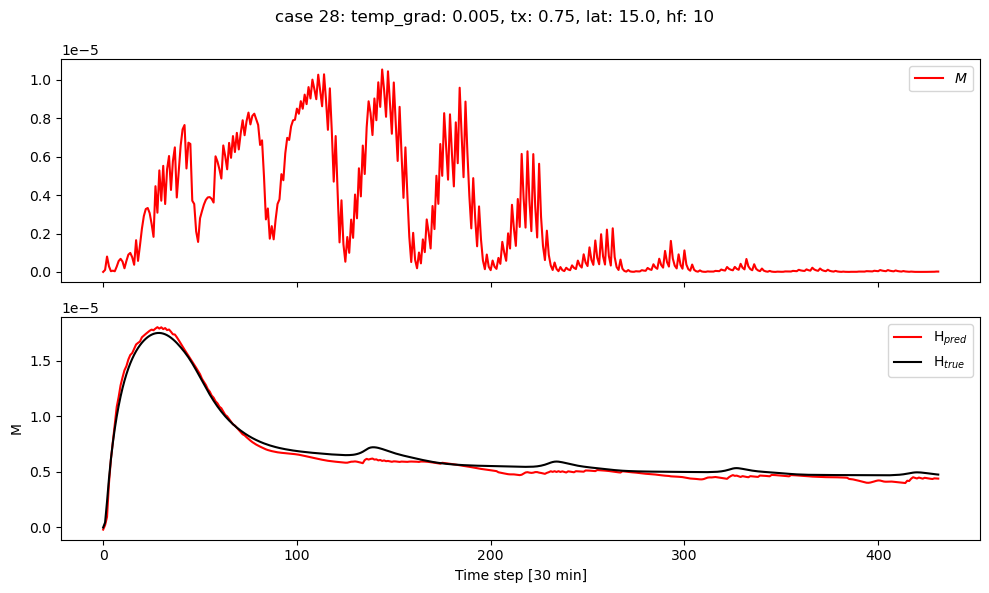

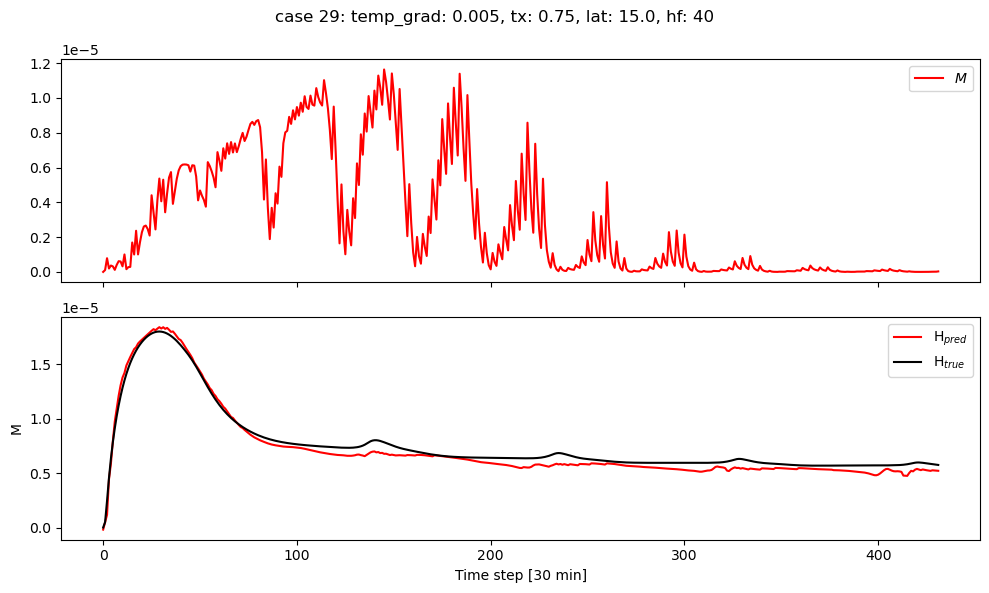

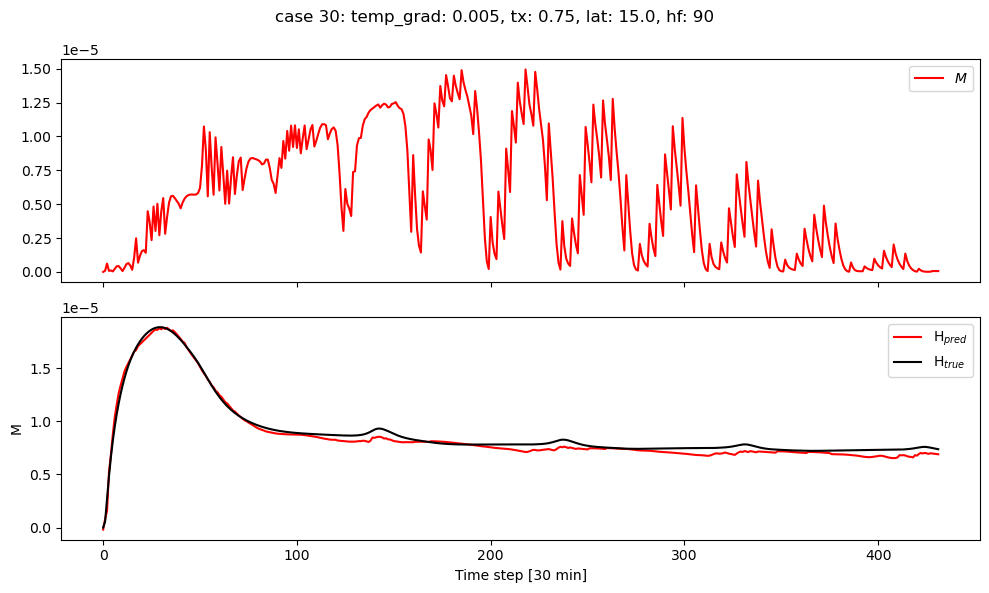

In [17]:
for i in range(30):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    fig, ax = plt.subplots(2,1,figsize=(10,6),tight_layout=True,sharex=True)
    plt.suptitle(f"case {i+1}: temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    ax[0].plot(X.detach().numpy()[config.n_time_steps*i:config.n_time_steps*(i+1),3], label="$M$", color="red")
    ax[0].legend()
    ax[1].plot(fcnn_prediction_val.detach().numpy()[config.n_time_steps*i:config.n_time_steps*(i+1)], label="H$_{pred}$", color="red")
    ax[1].plot(y_val[config.n_time_steps*i:config.n_time_steps*(i+1)], label="H$_{true}$", color="black")
    ax[1].set_xlabel("Time step [30 min]")
    ax[1].set_ylabel("M")
    ax[1].legend()

In [79]:
y_val.detach().numpy().reshape(-1,430).shape

(216, 430)

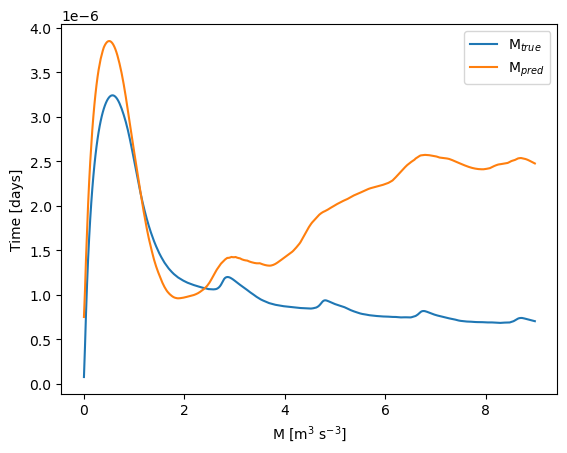

In [13]:
i=2

time = np.arange(0, config.n_time_steps_val, 1) / 2 / 24

plt.plot(time, np.cumsum(y_val.detach().numpy().reshape(-1,432), axis=1)[i], label="M$_{true}$")
plt.plot(time, np.cumsum(fcnn_prediction_val.detach().numpy().reshape(-1,432), axis=1)[i], label="M$_{pred}$")
plt.ylabel("Time [days]")
plt.xlabel("M [m$^3$ s$^{-3}$]")

plt.legend()

In [14]:
M_true = recover_M_from_dM(
    dM=y_val.detach().numpy(),
    n_time_steps=config.n_time_steps_val
)

M_pred = recover_M_from_dM(
    dM=fcnn_prediction_val.detach().numpy(),
    n_time_steps=config.n_time_steps_val
)

In [20]:
config.n_time_steps=433

/tmp/ipykernel_838453/2980931432.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(2,1,figsize=(10,6),tight_layout=True,sharex=True)


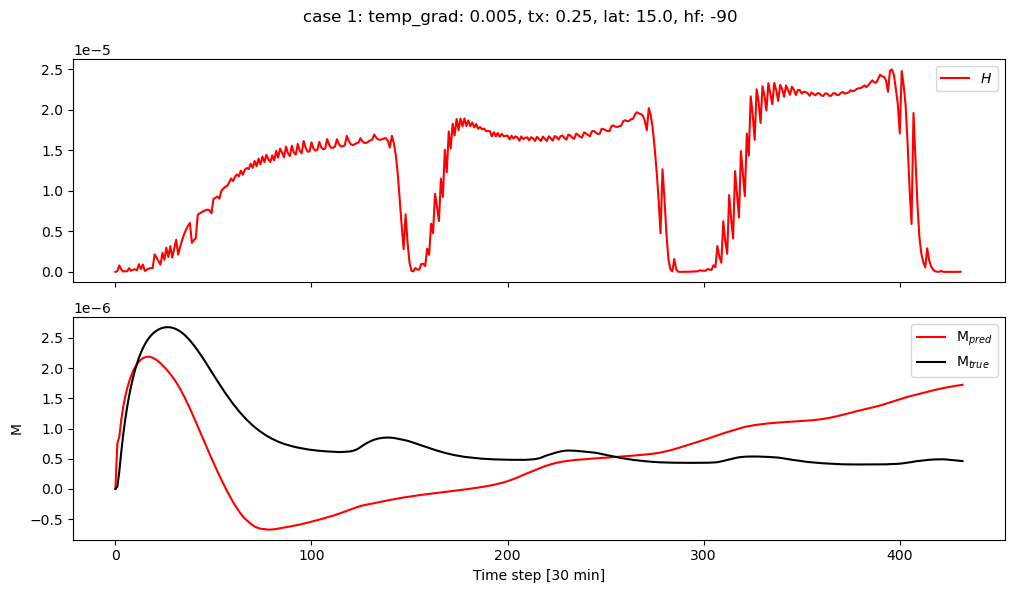

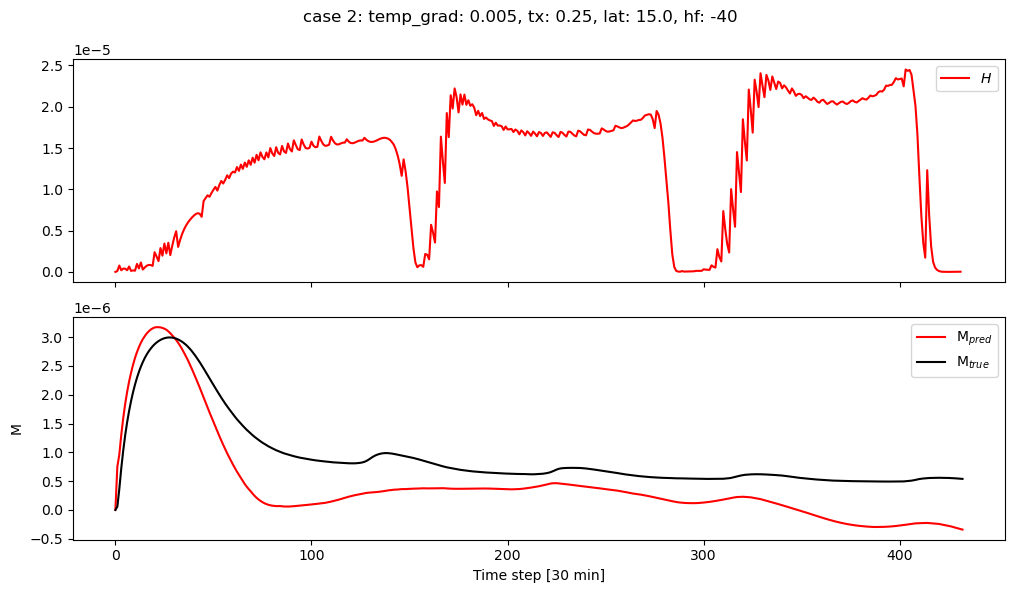

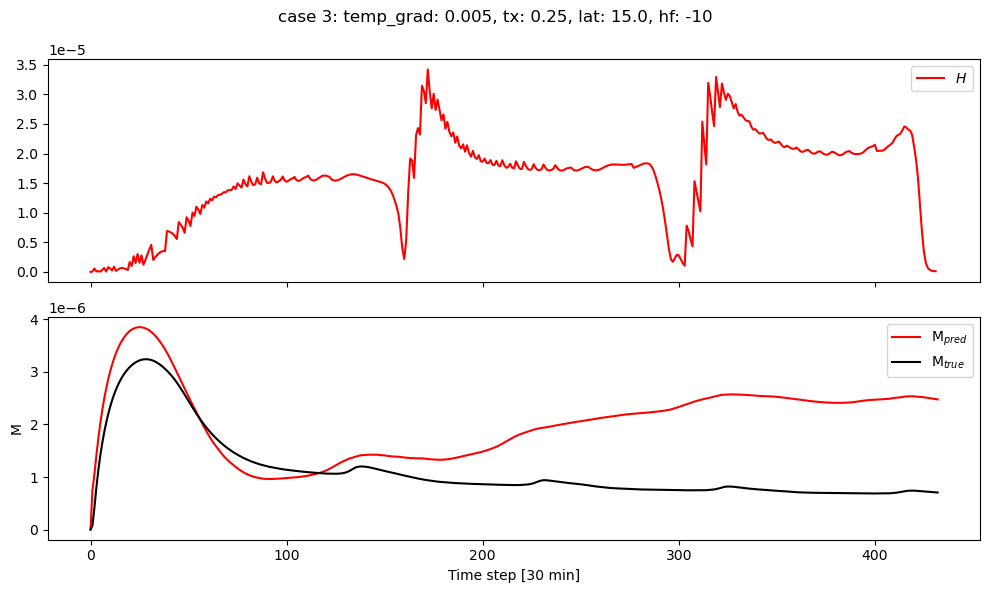

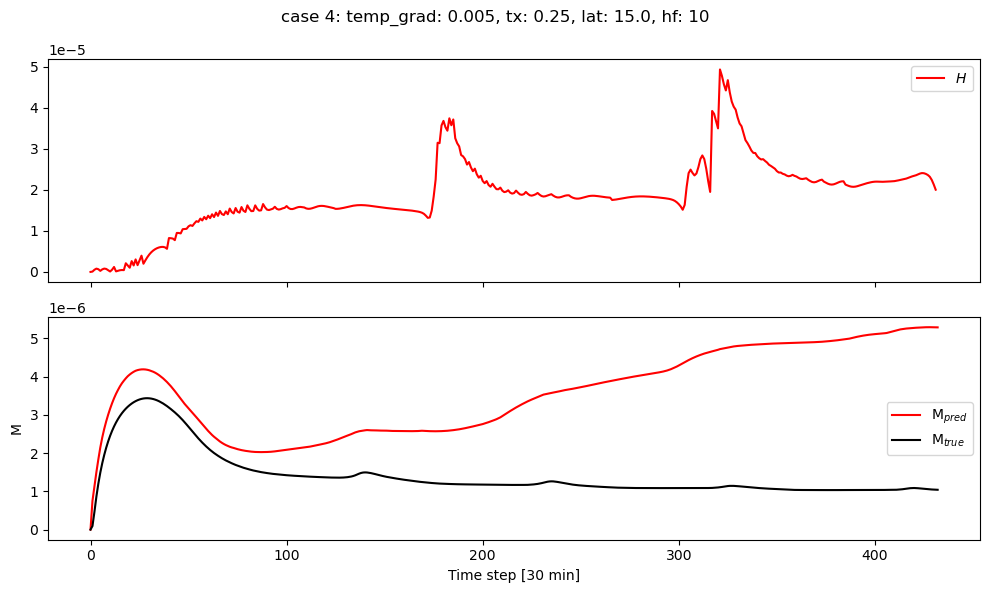

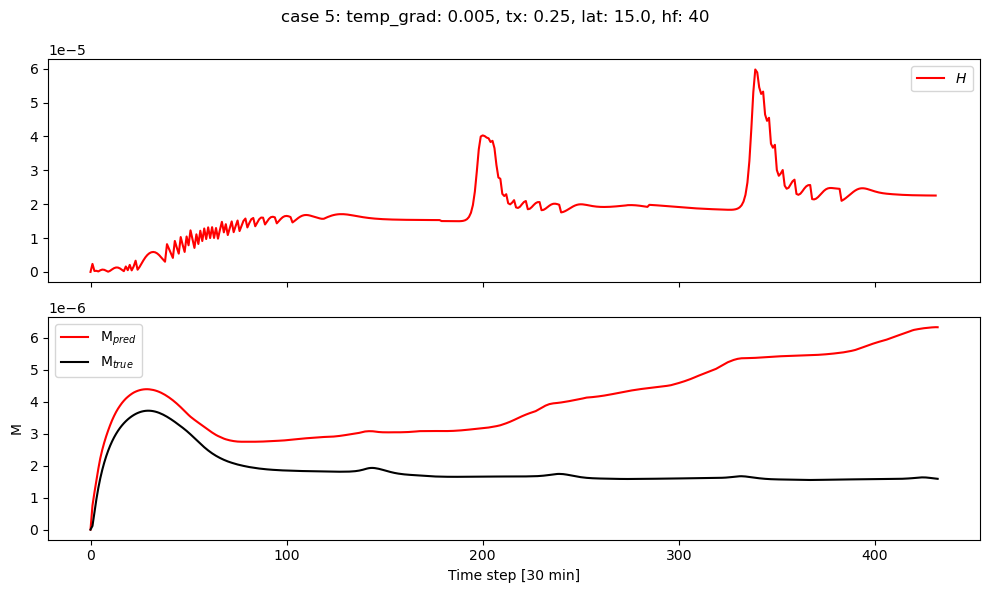

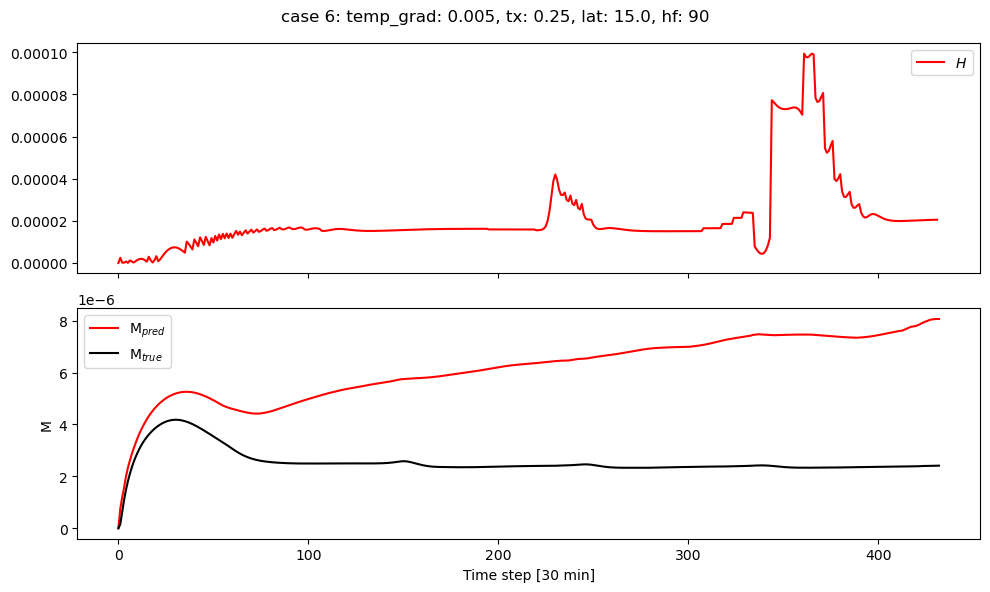

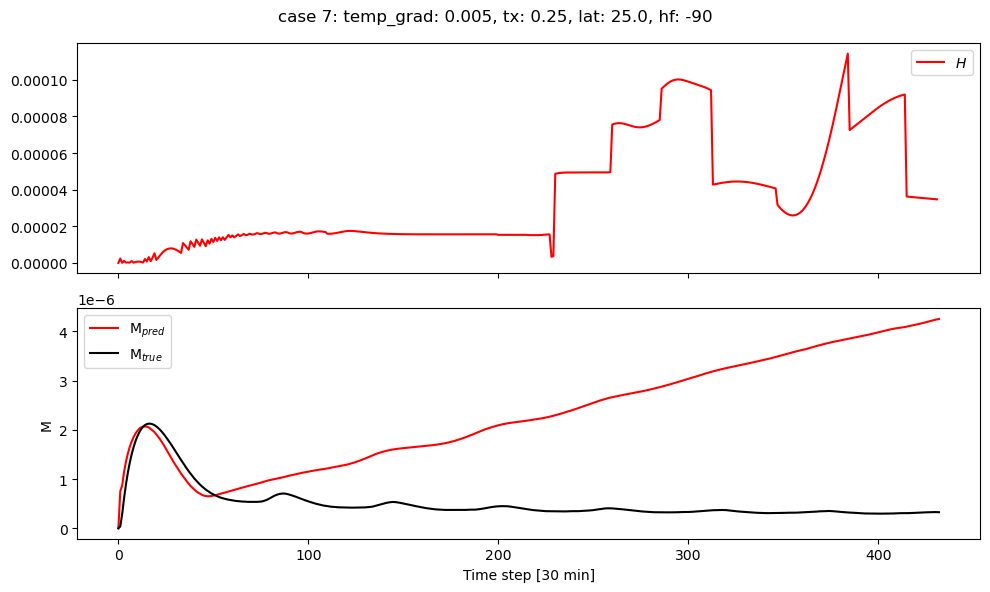

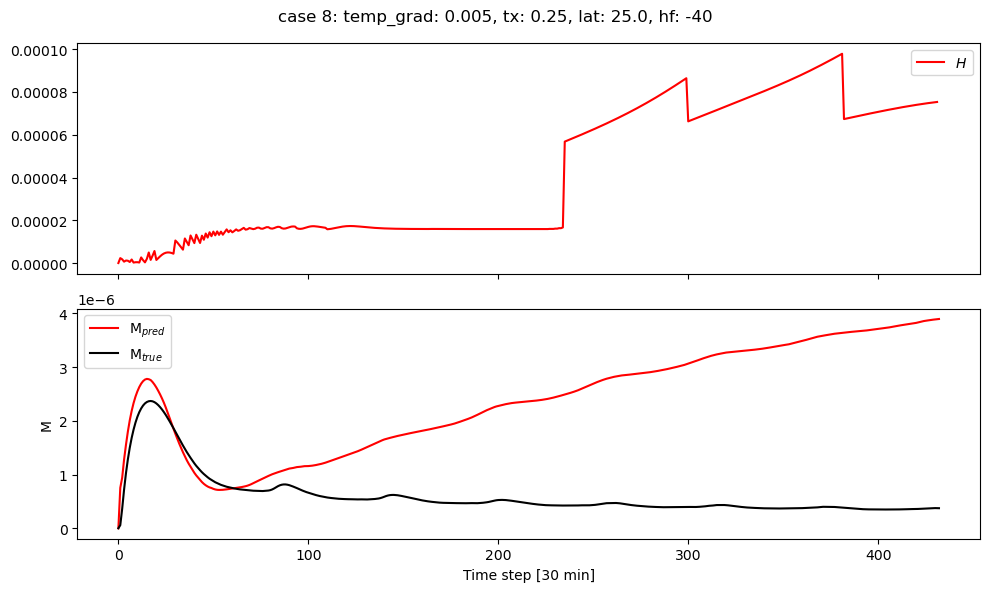

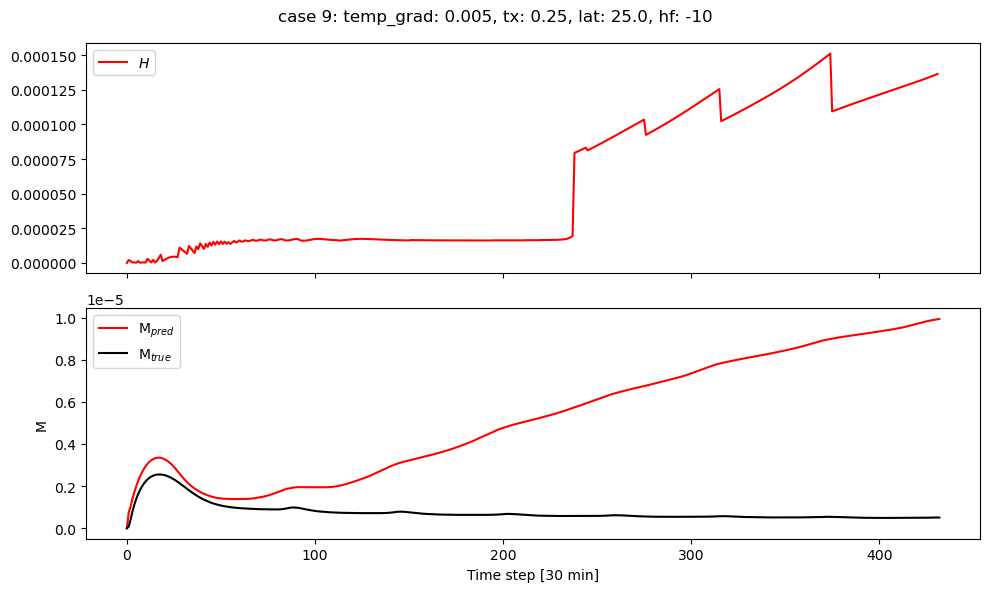

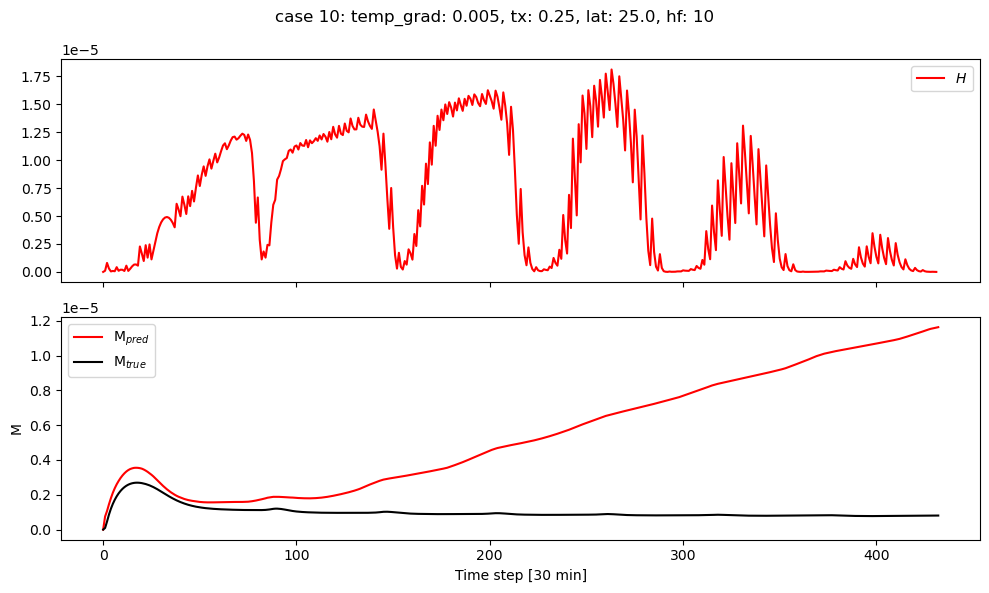

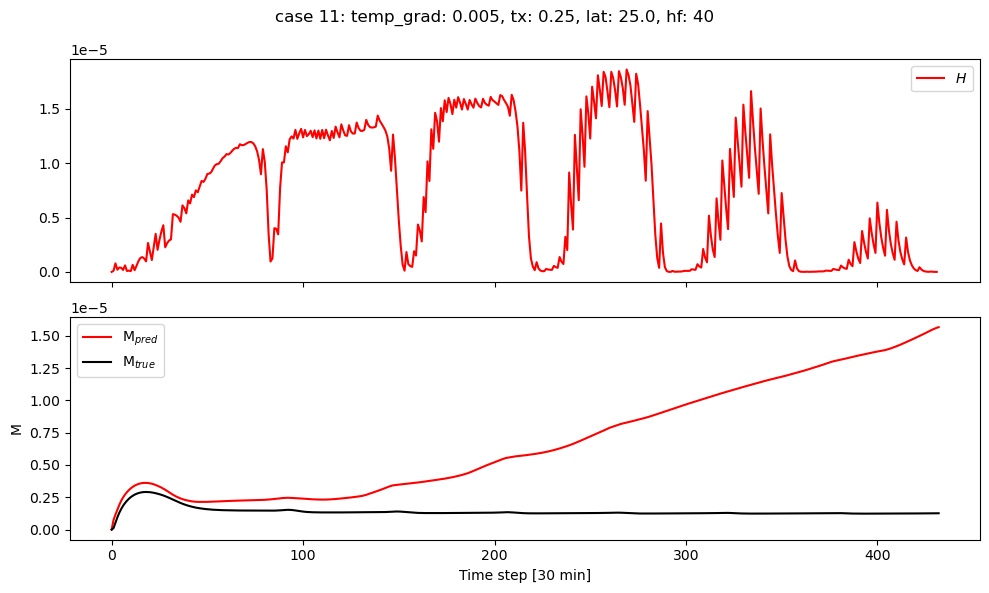

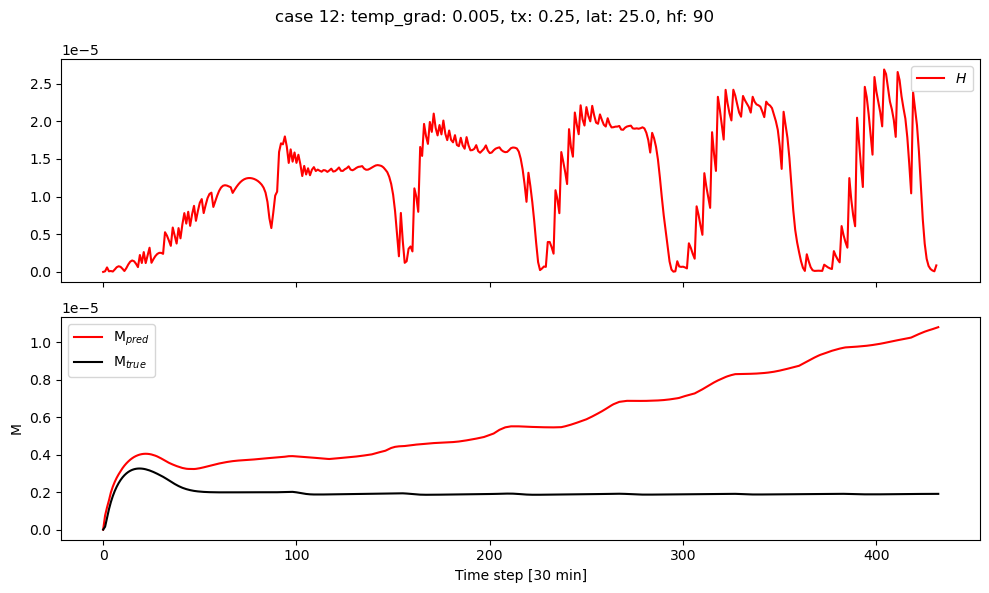

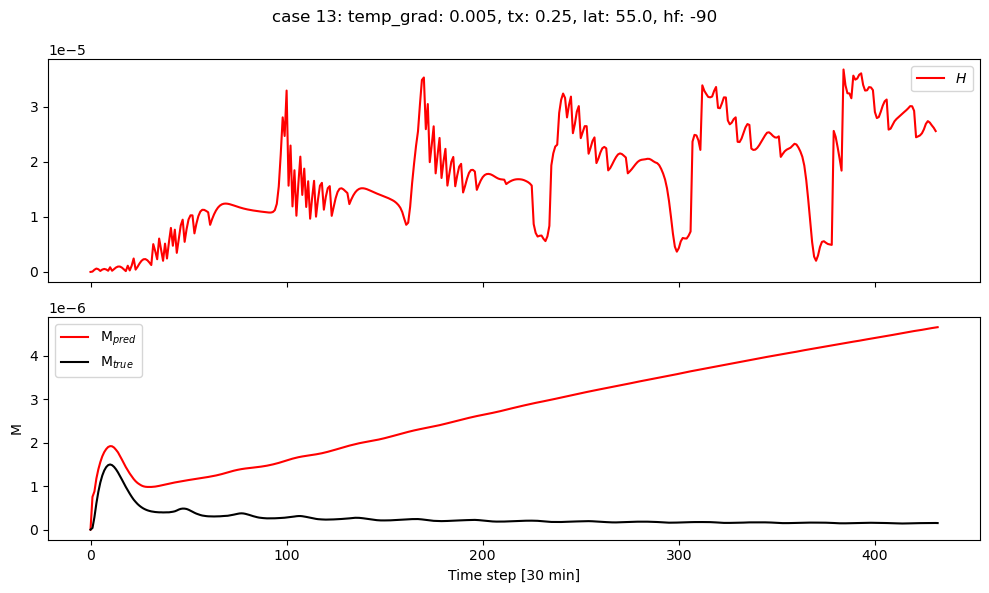

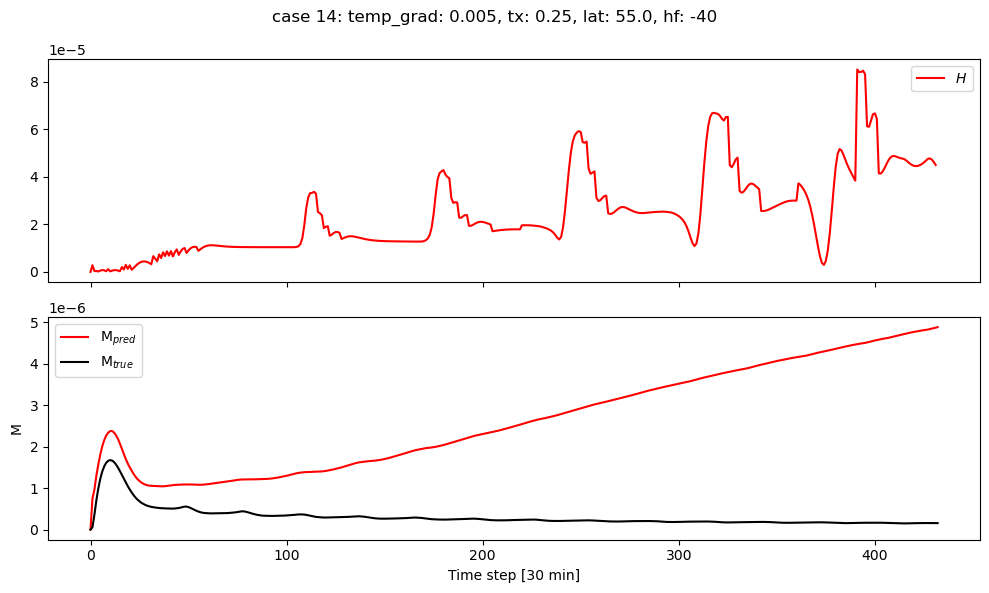

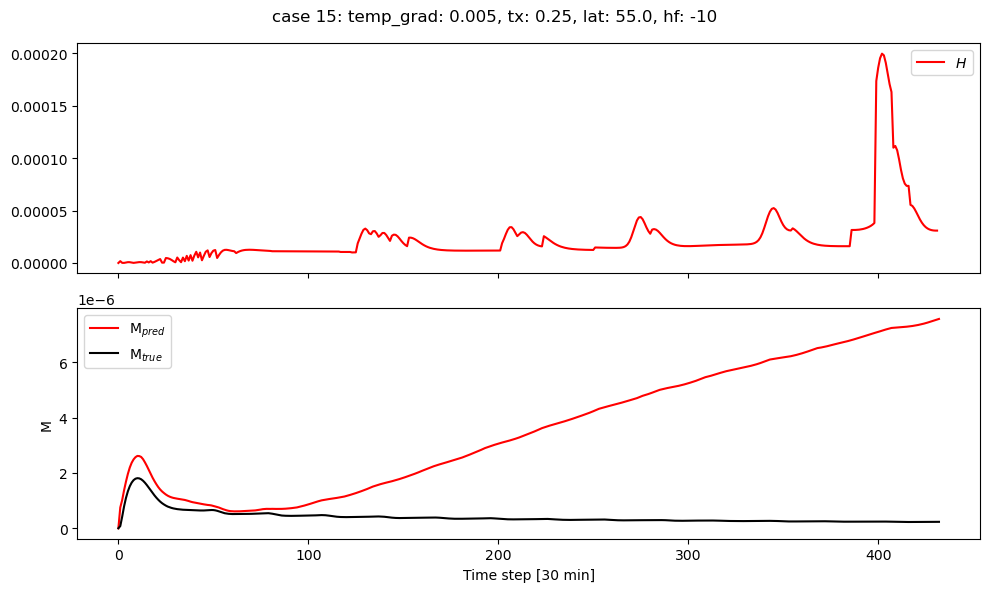

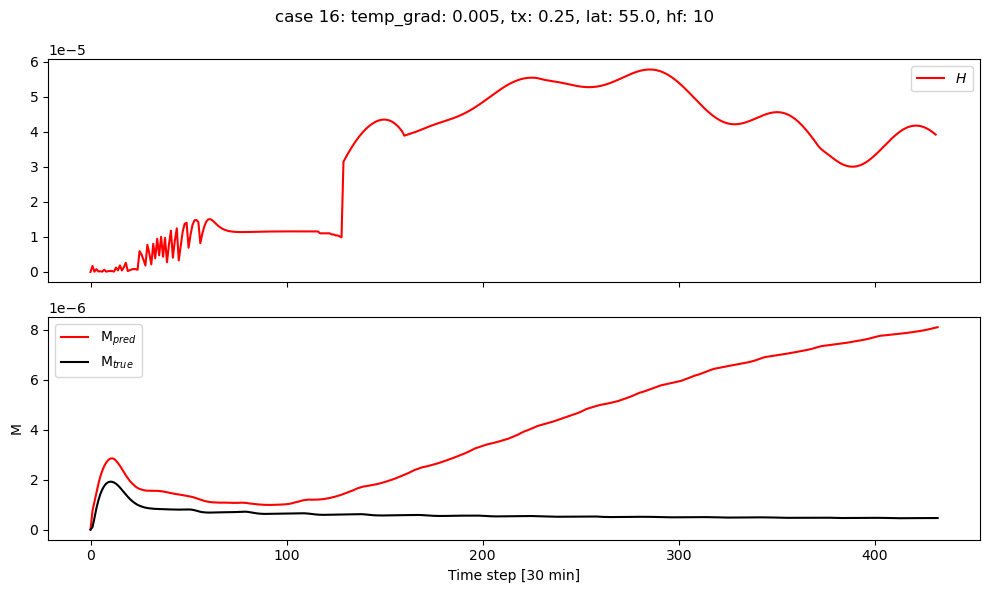

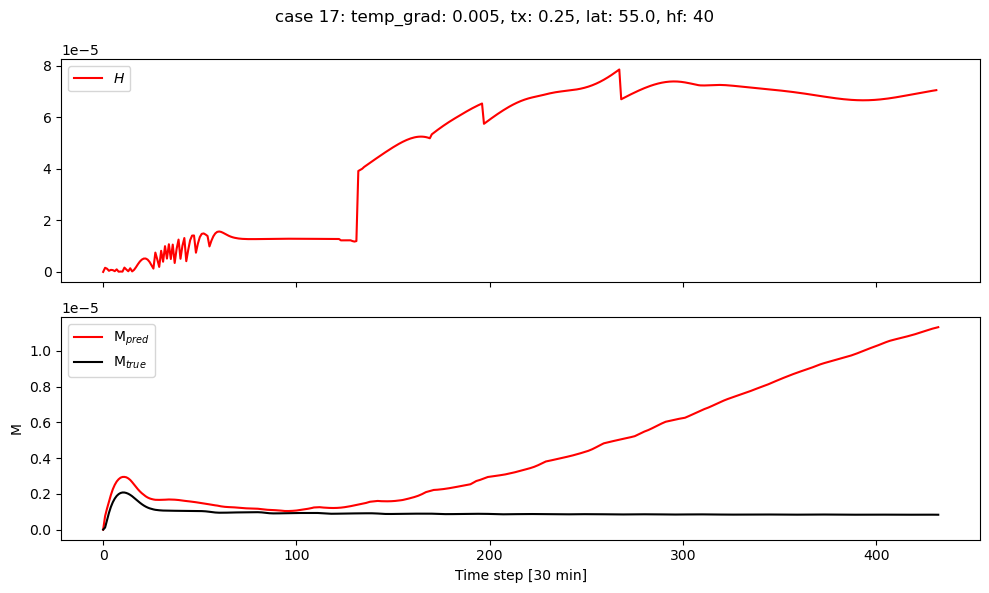

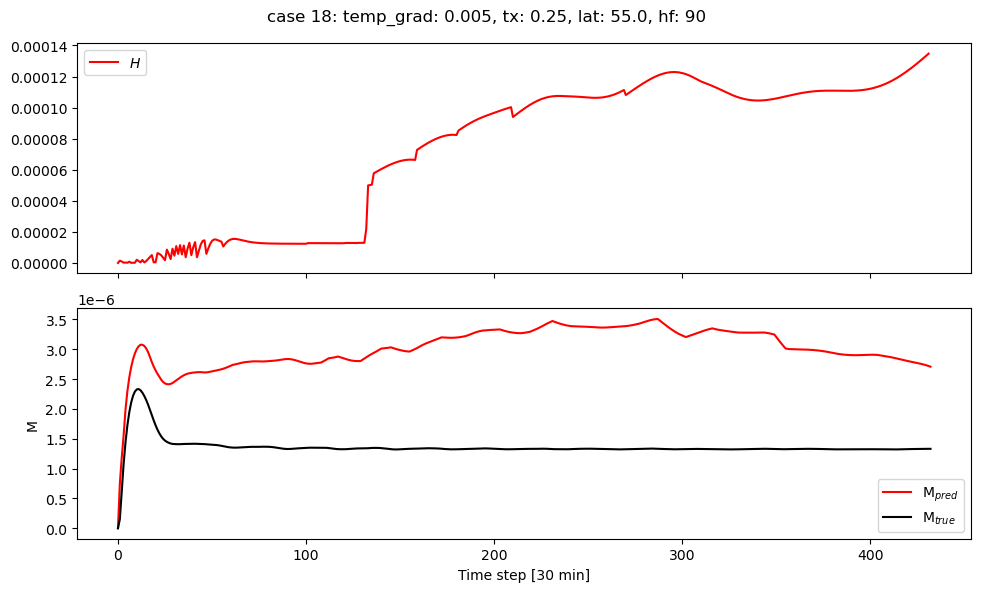

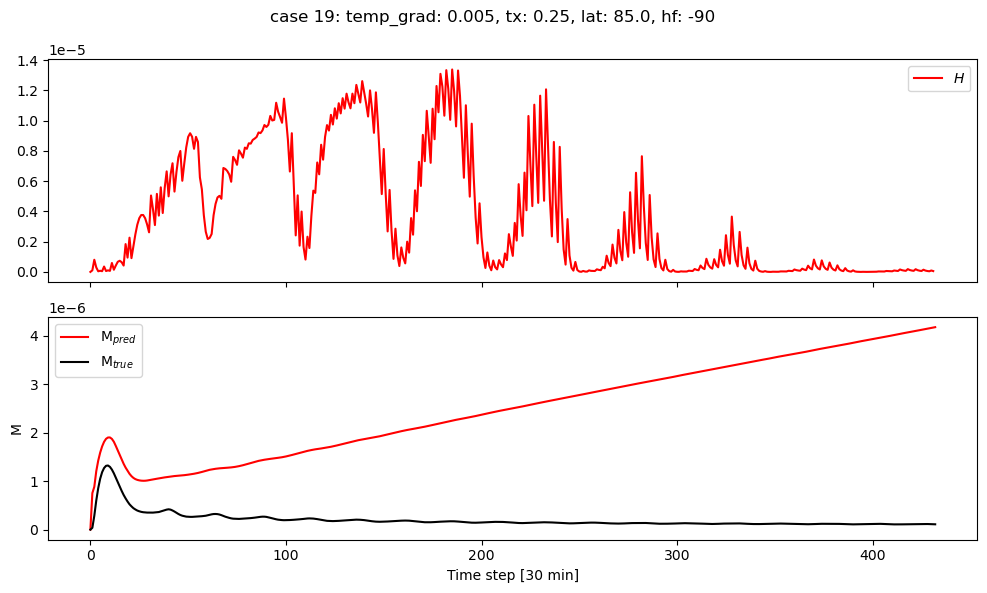

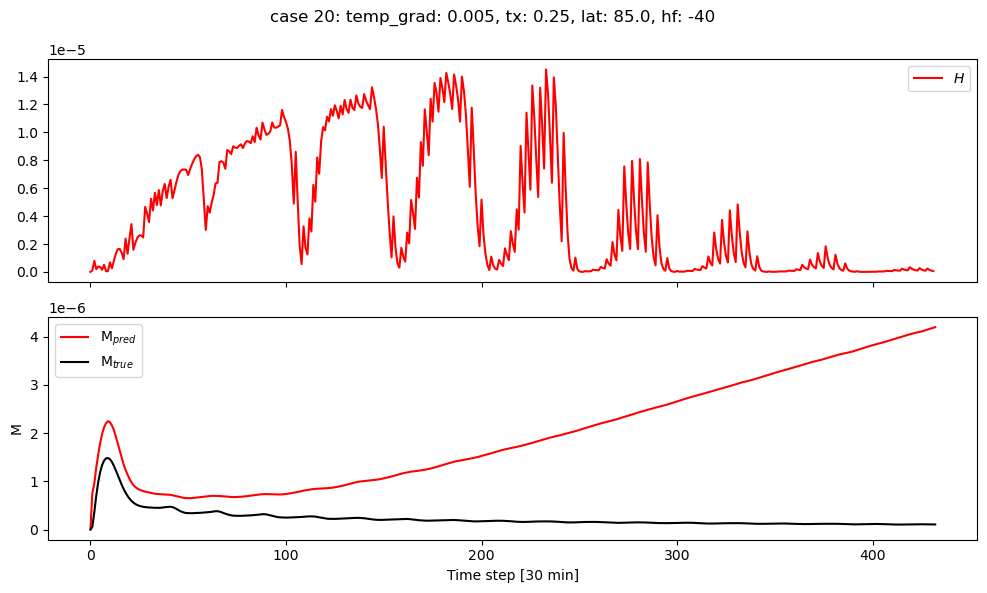

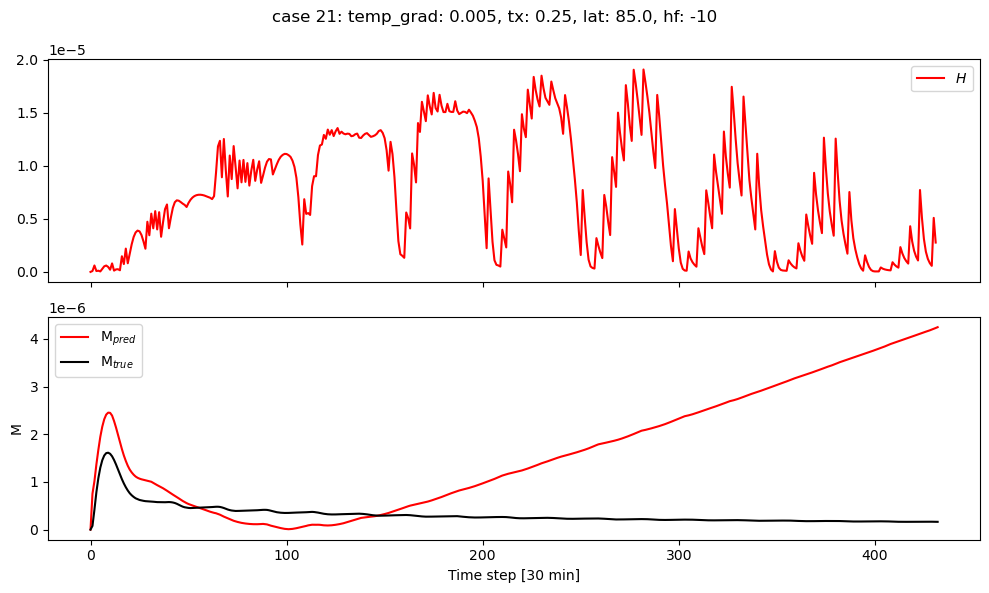

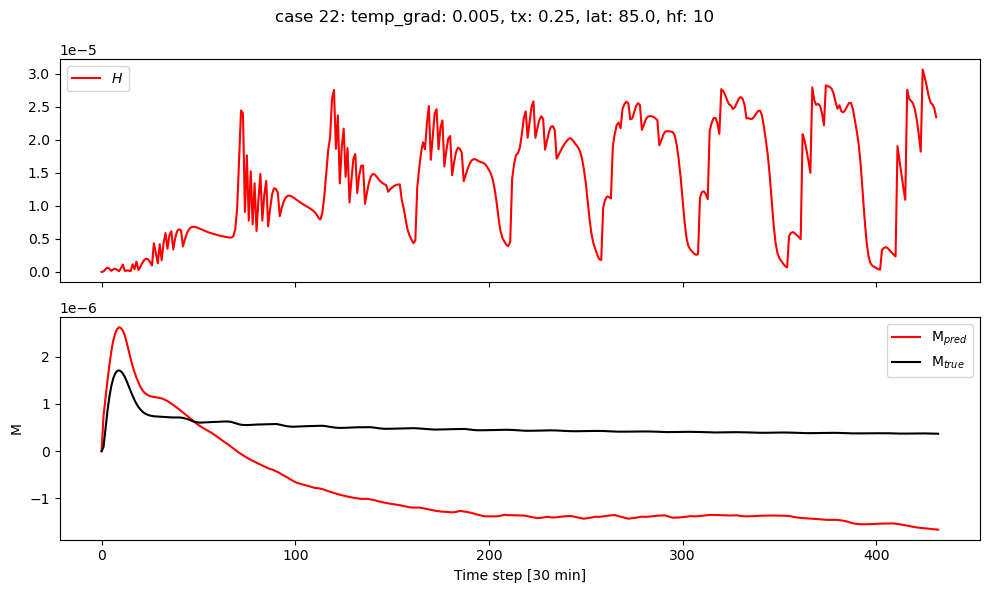

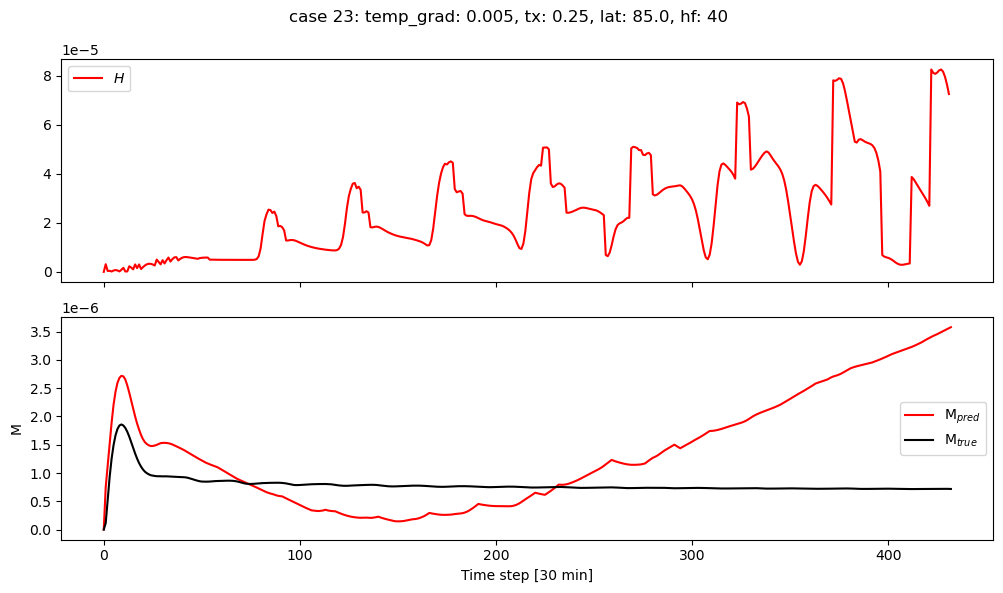

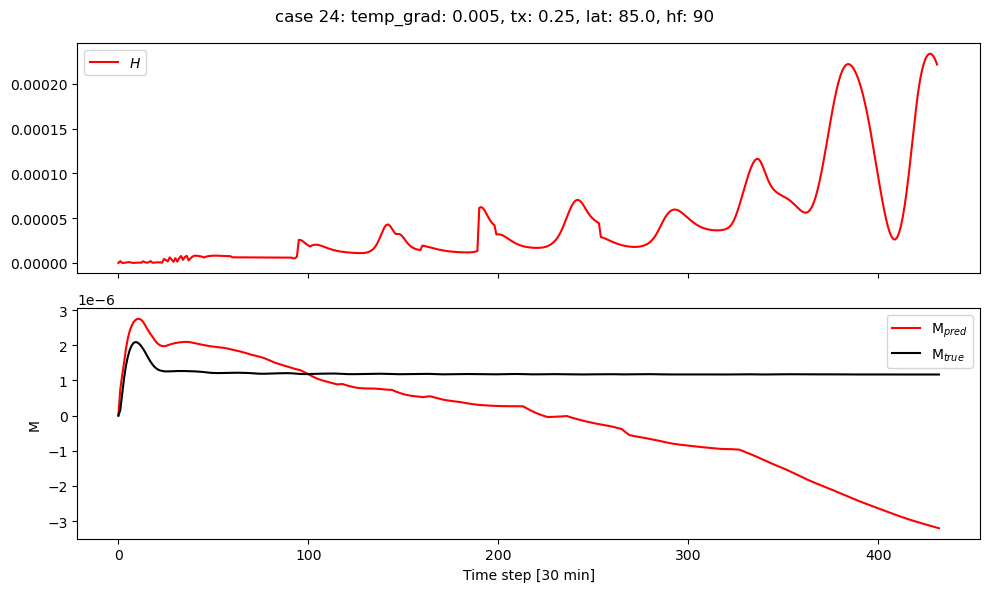

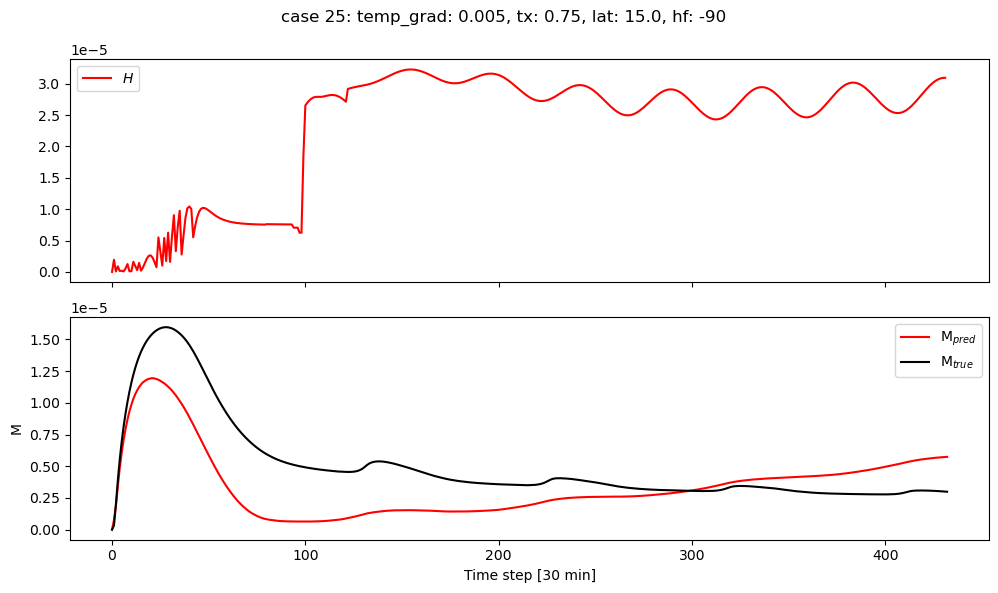

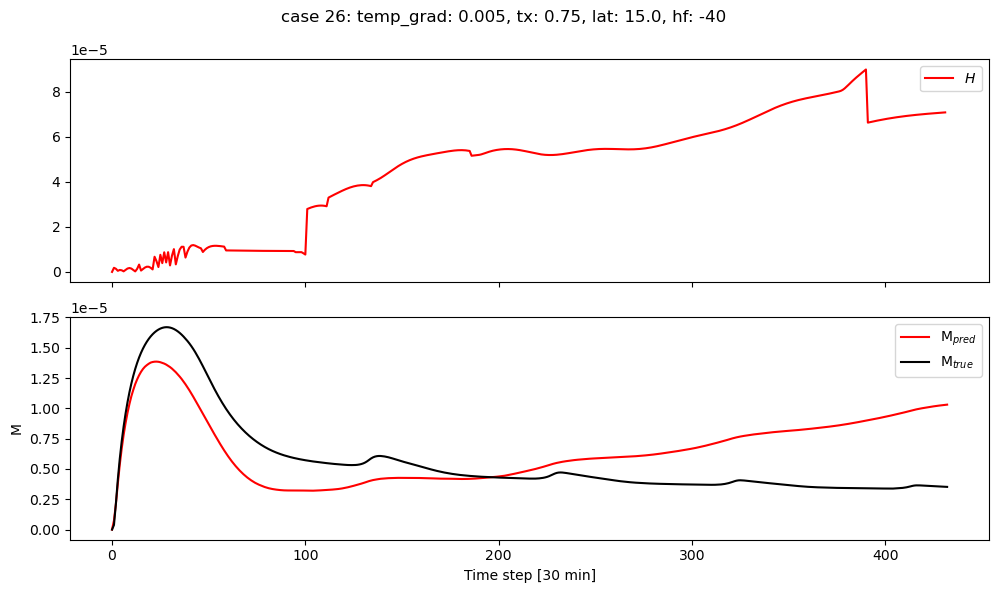

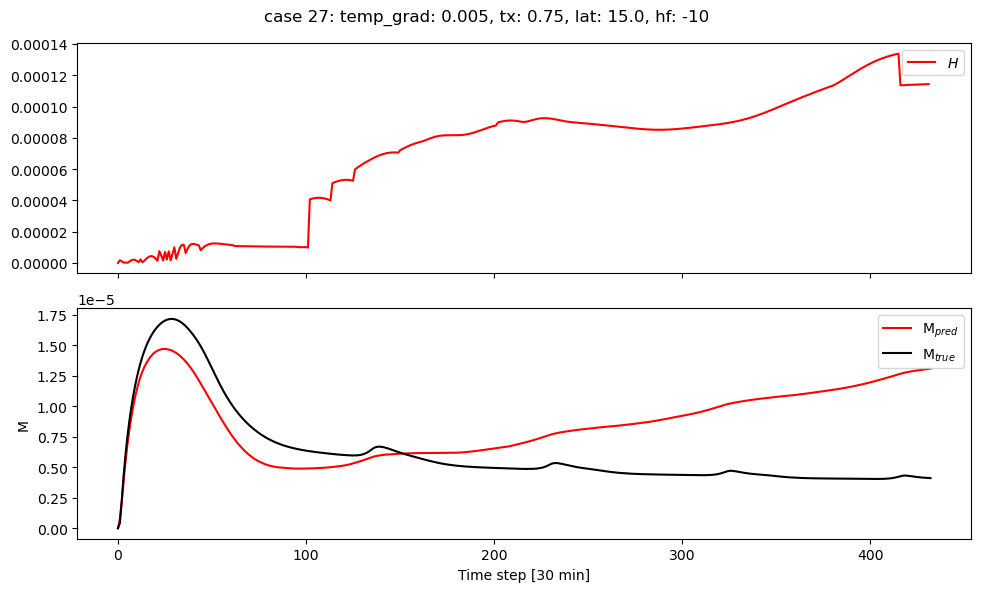

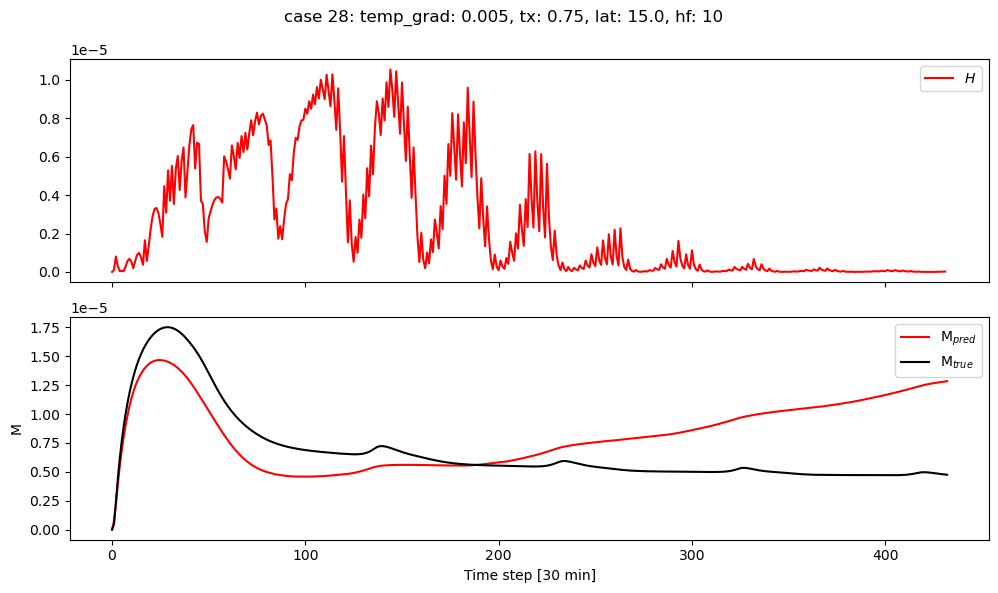

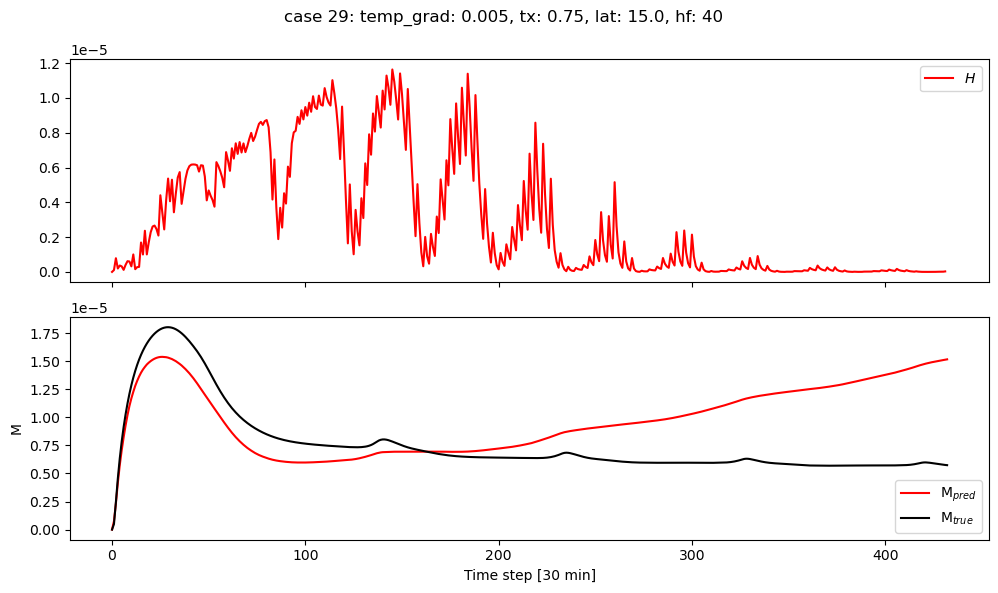

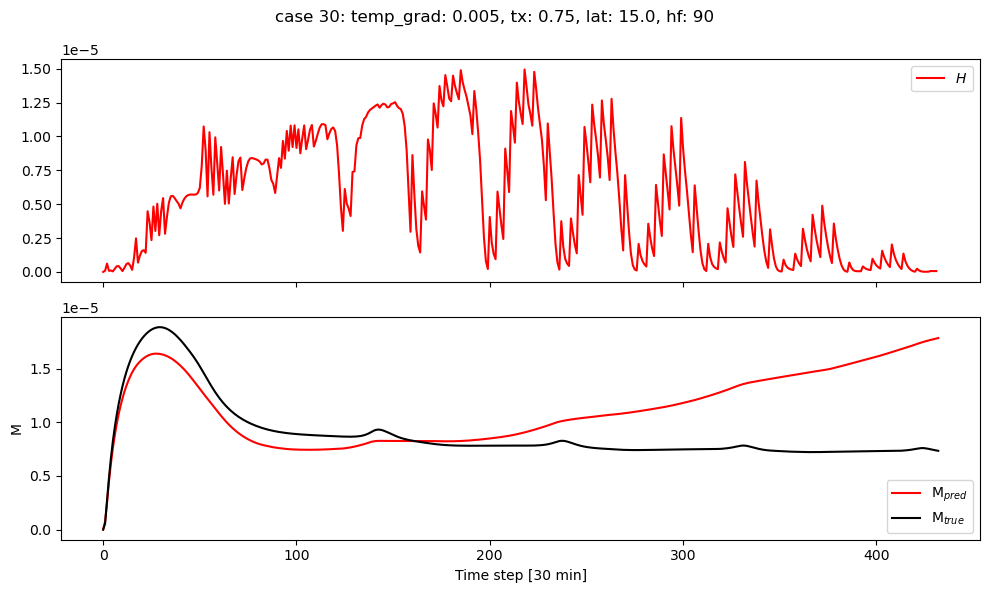

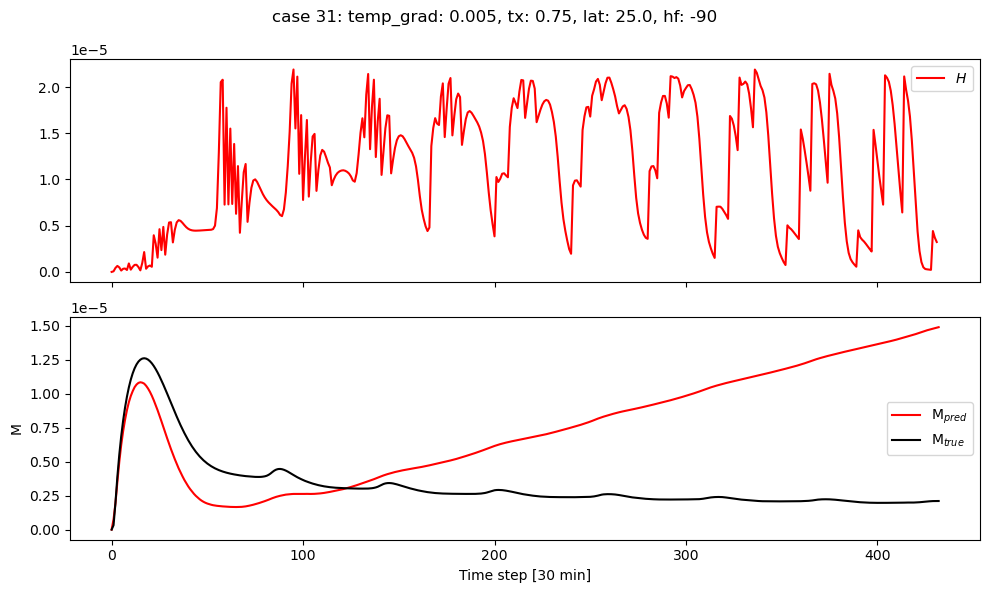

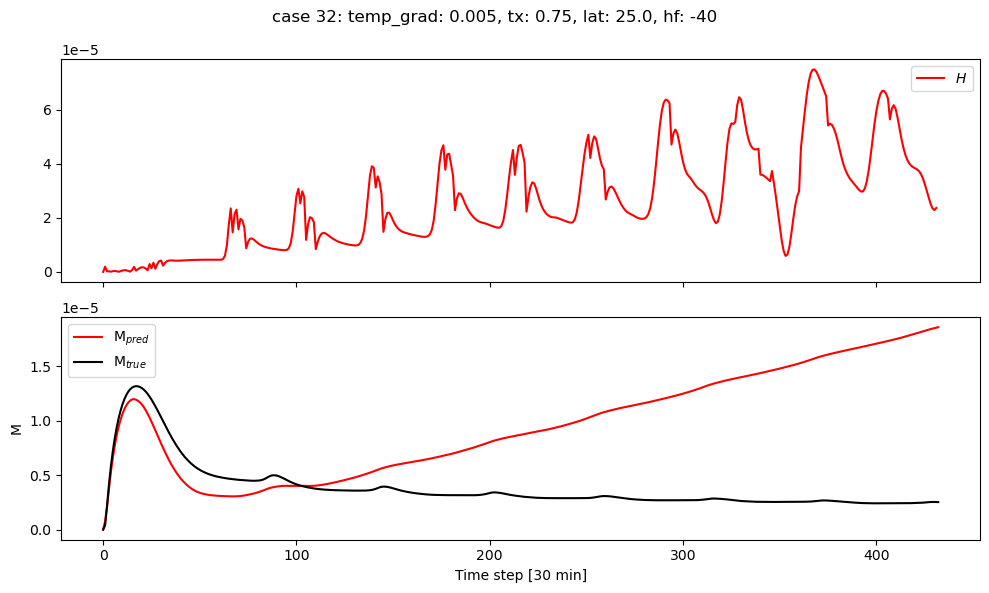

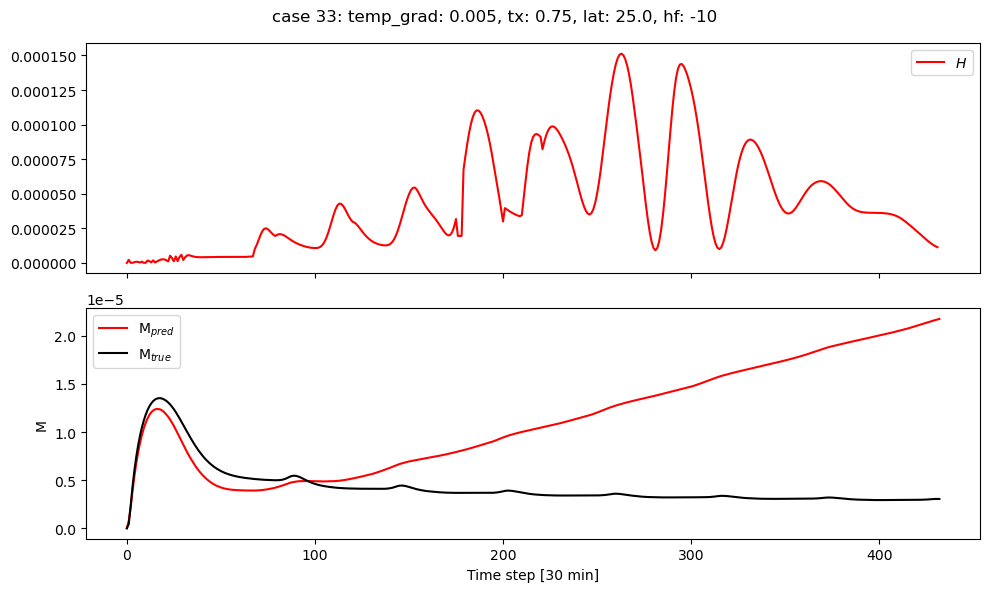

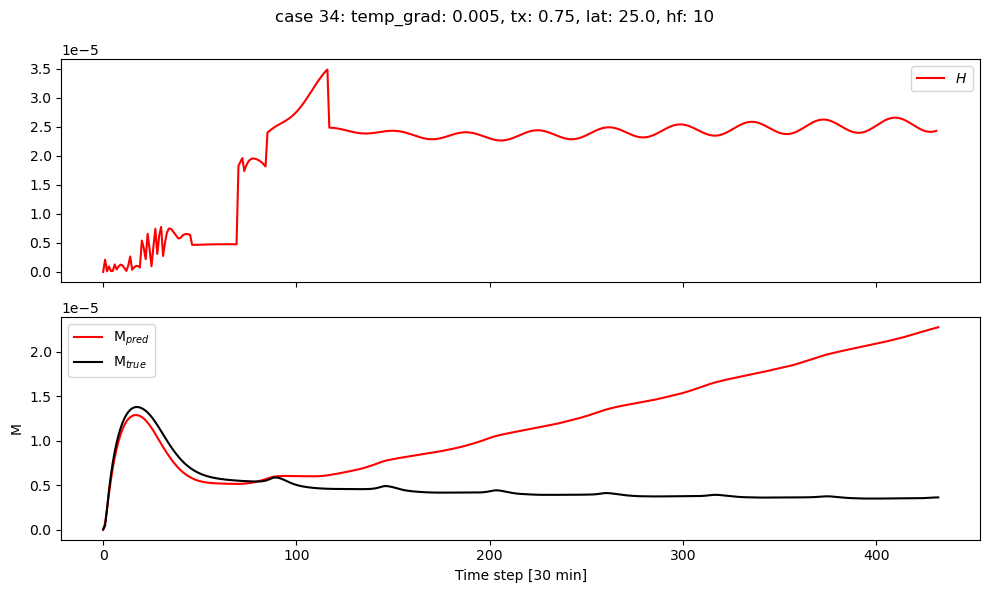

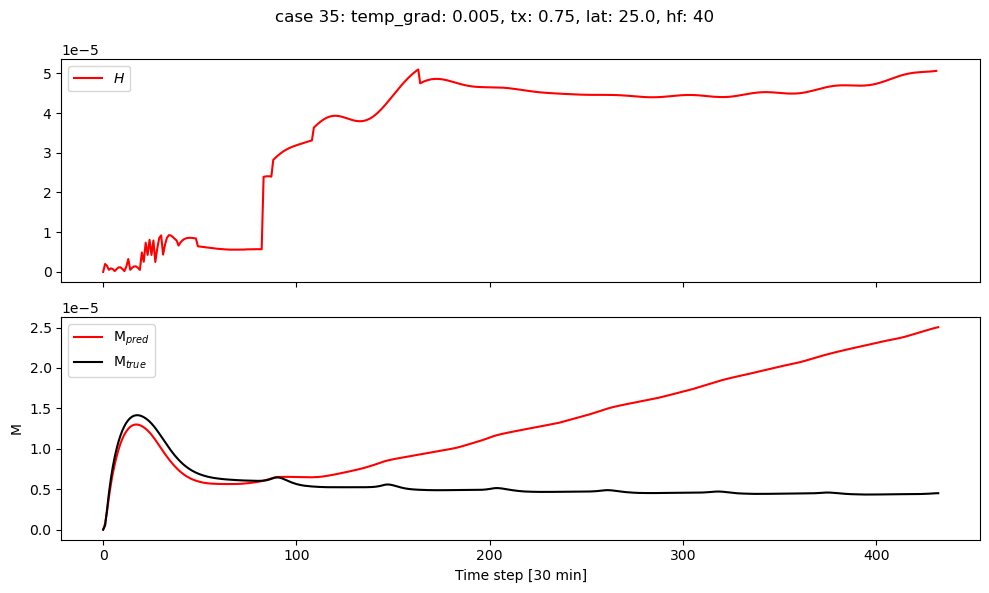

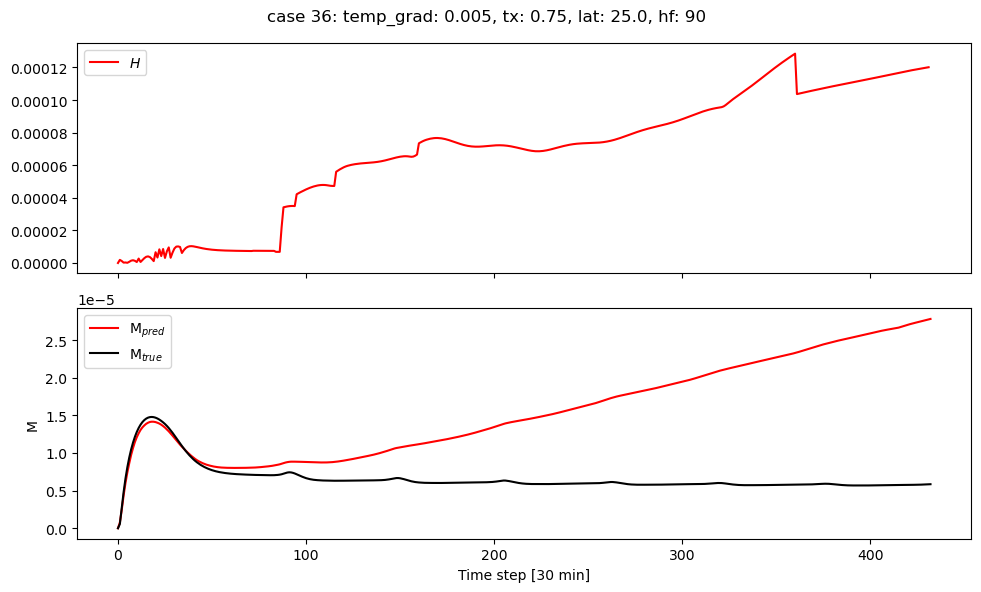

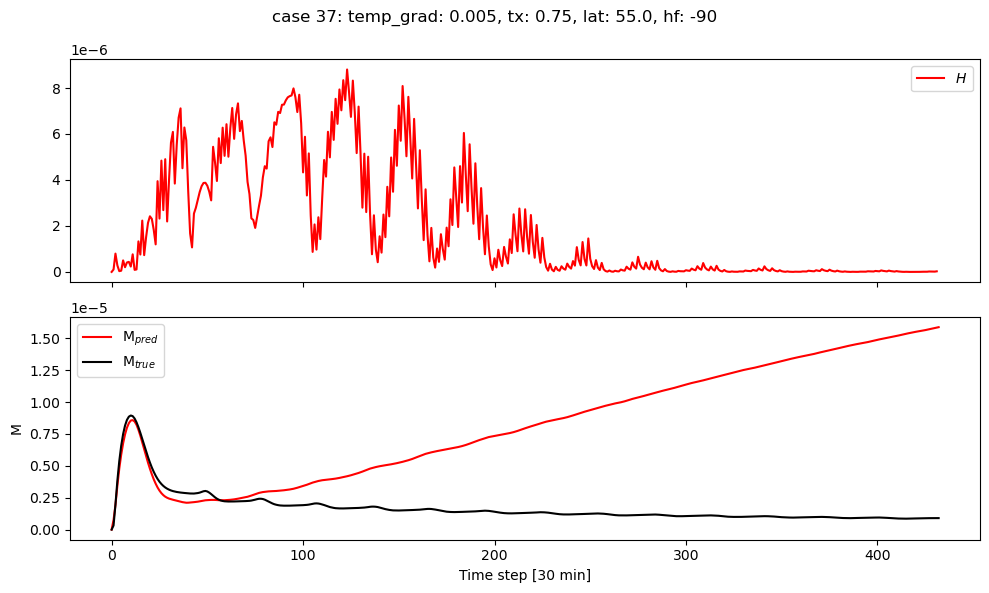

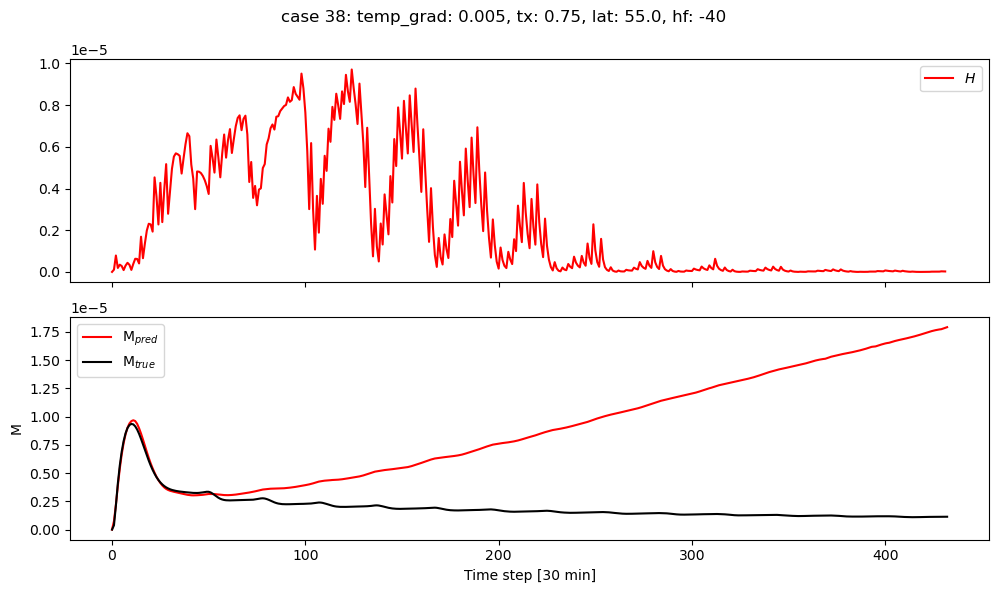

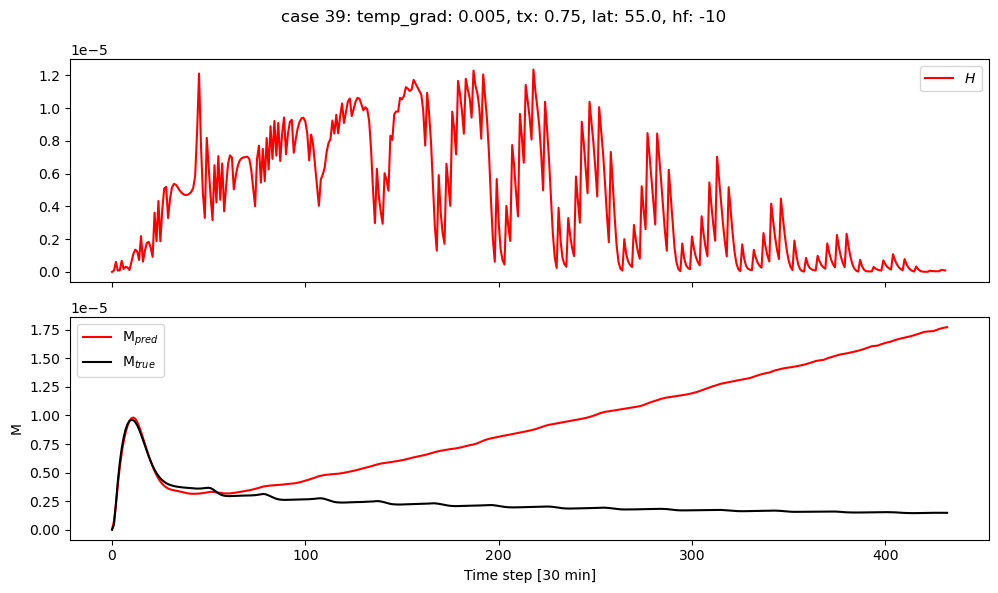

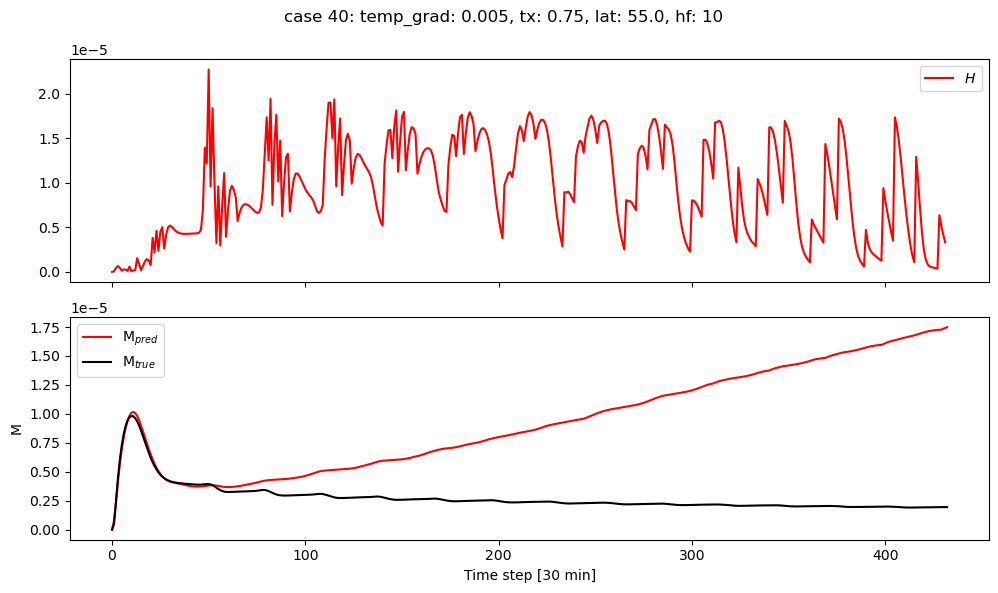

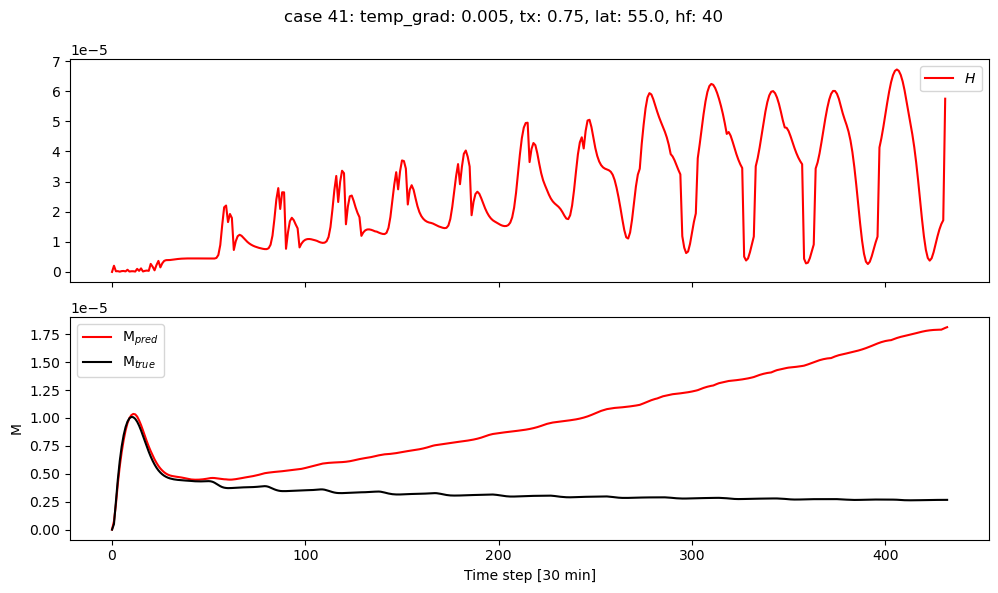

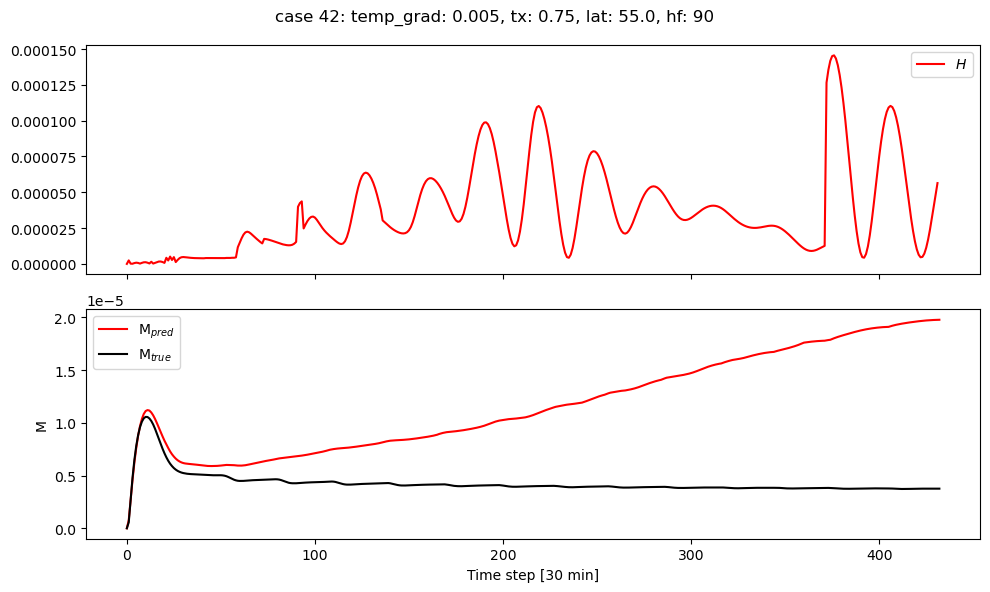

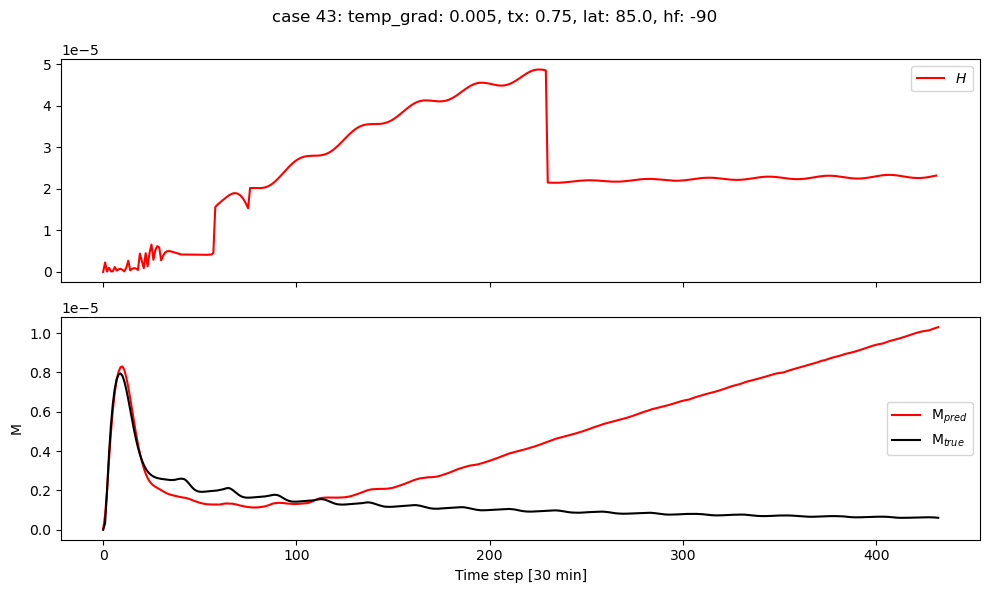

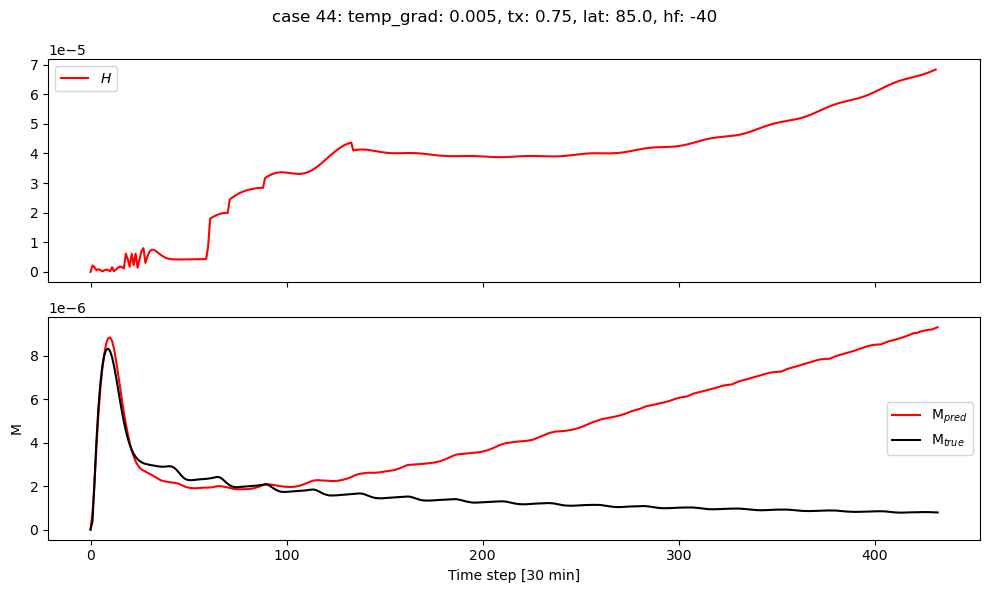

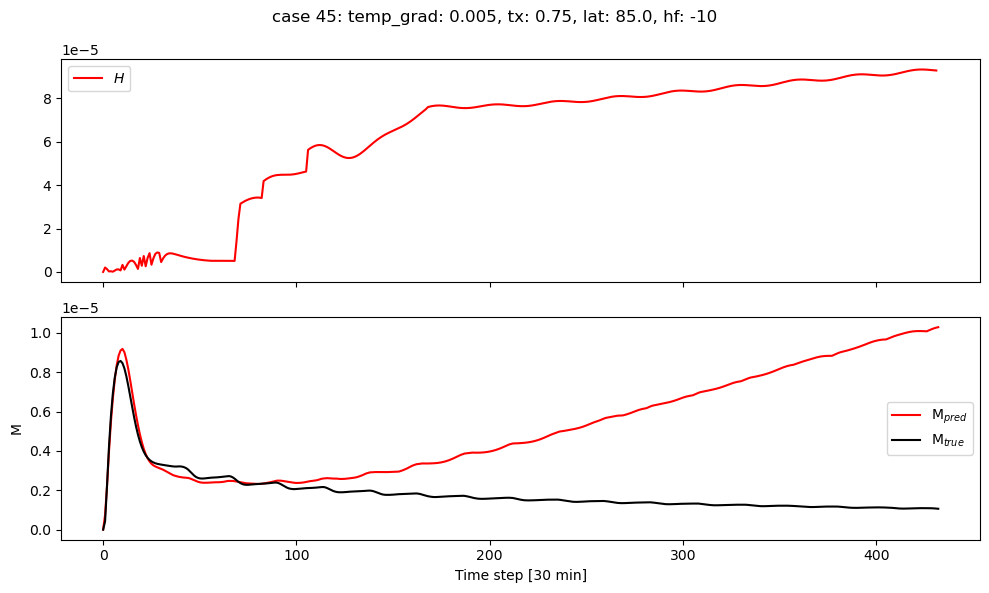

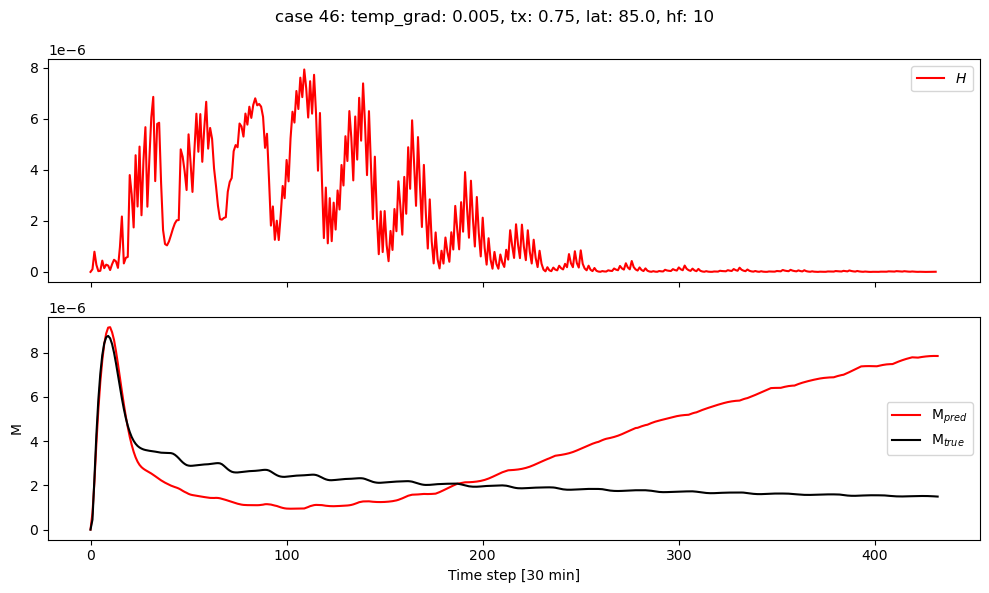

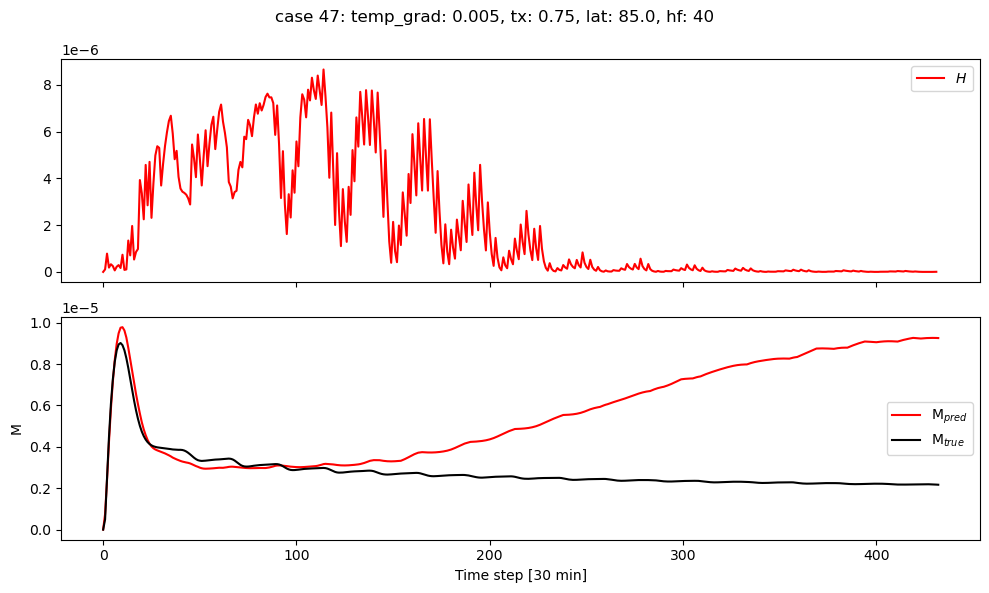

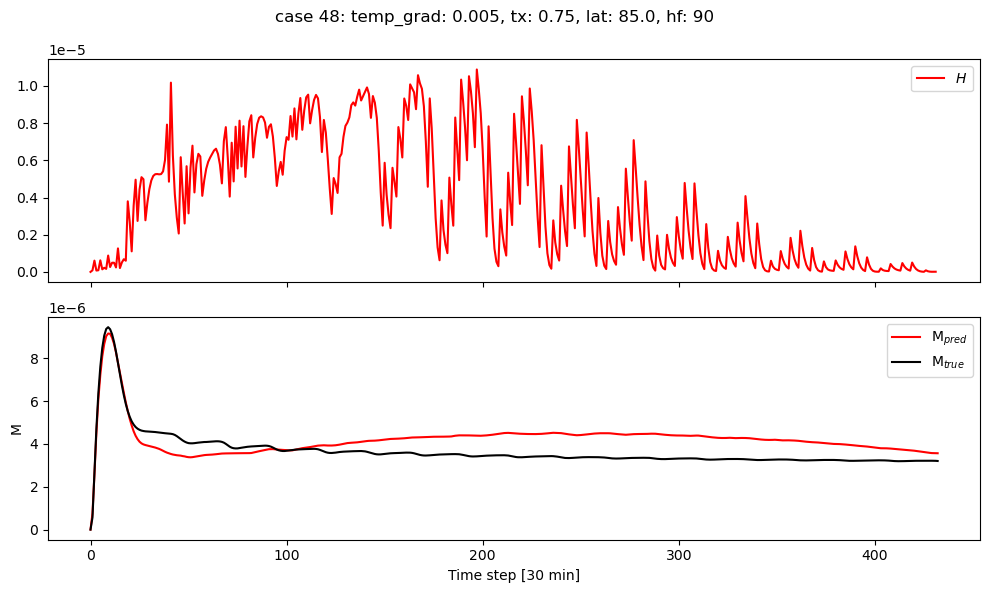

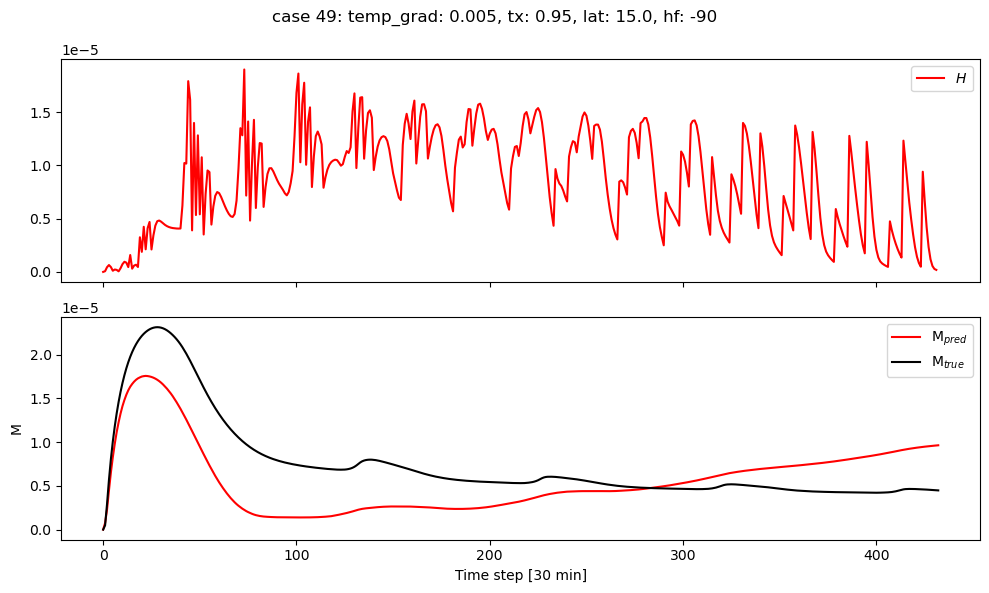

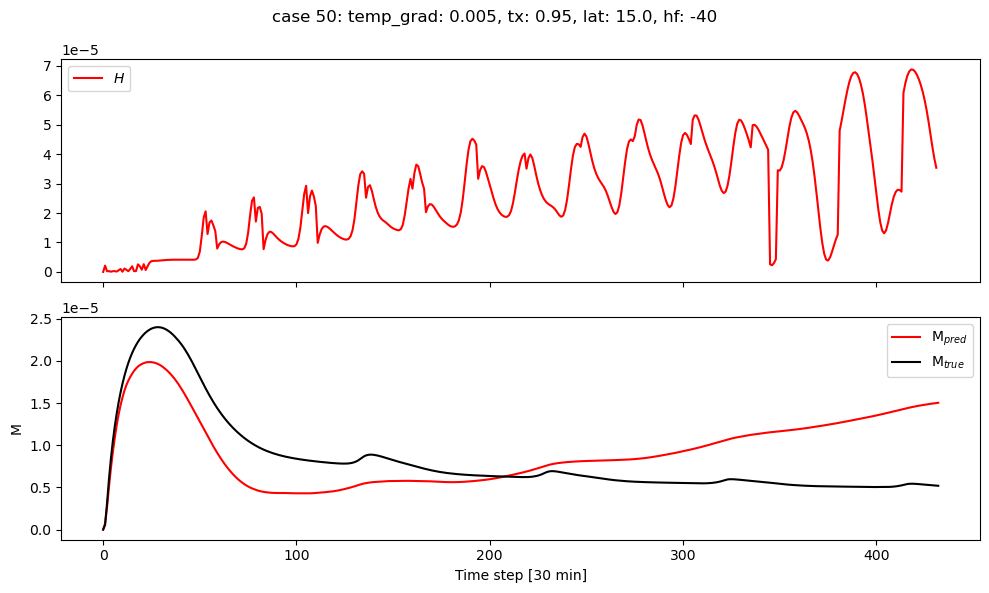

In [22]:
for i in range(0,50):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    fig, ax = plt.subplots(2,1,figsize=(10,6),tight_layout=True,sharex=True)
    plt.suptitle(f"case {i+1}: temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    ax[0].plot(X.detach().numpy()[config.n_time_steps_val*i:config.n_time_steps_val*(i+1),3], label="$H$", color="red")
    ax[0].legend()
    ax[1].plot(M_pred[config.n_time_steps*i:config.n_time_steps*(i+1)], label="M$_{pred}$", color="red")
    ax[1].plot(M_true[config.n_time_steps*i:config.n_time_steps*(i+1)], label="M$_{true}$", color="black")
    ax[1].set_xlabel("Time step [30 min]")
    ax[1].set_ylabel("M")
    ax[1].legend()

In [23]:
np.sqrt(np.mean((M_pred-M_true)**2))

4.5067927e-06

/tmp/ipykernel_1862538/3438415172.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(1,1,figsize=(10,4),tight_layout=True,sharex=True)


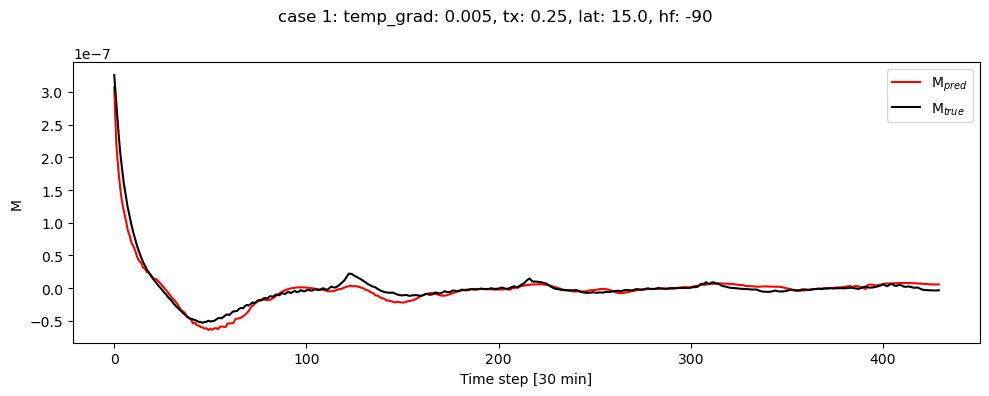

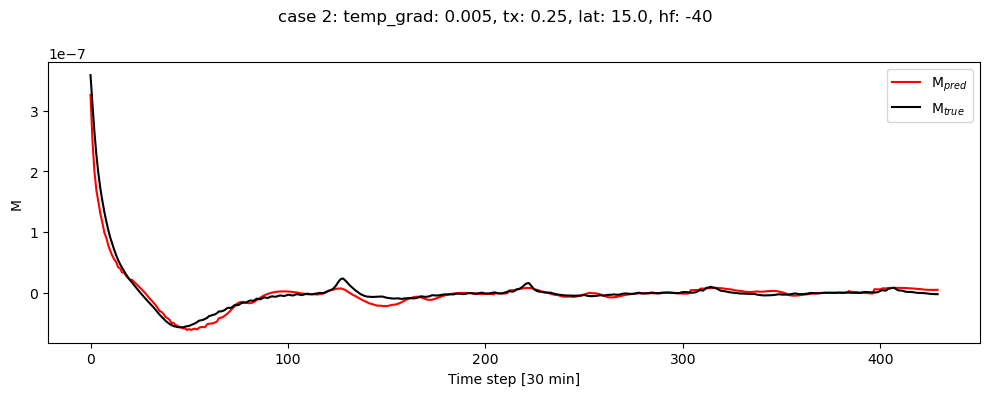

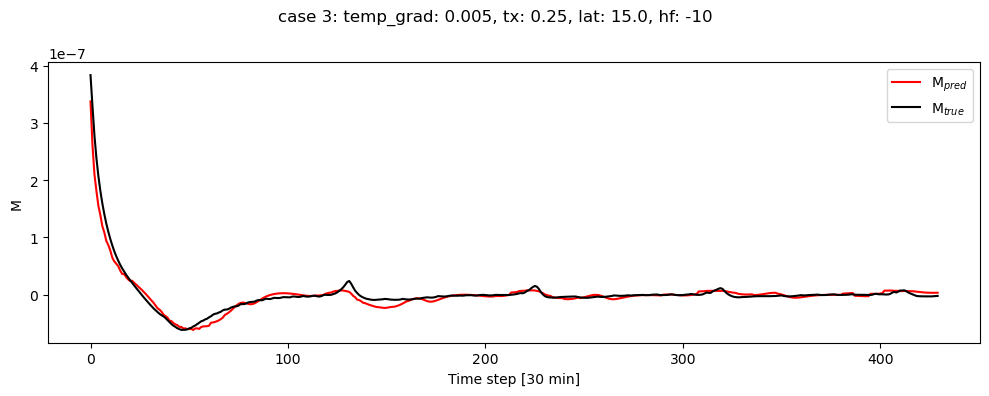

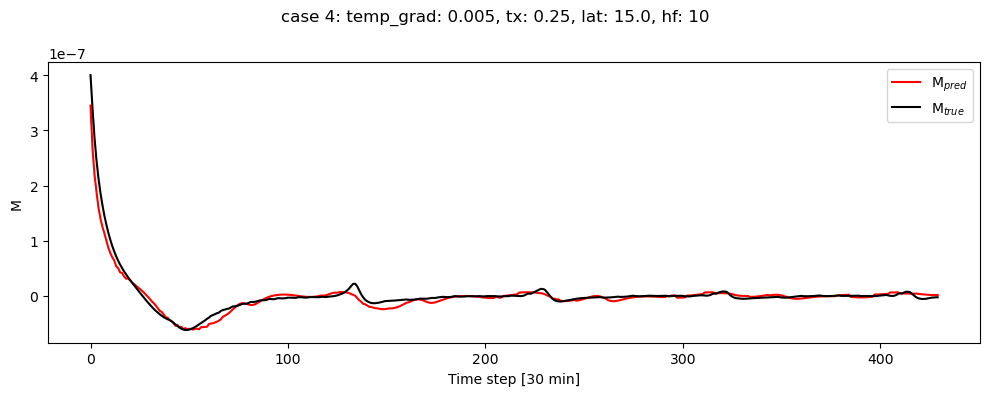

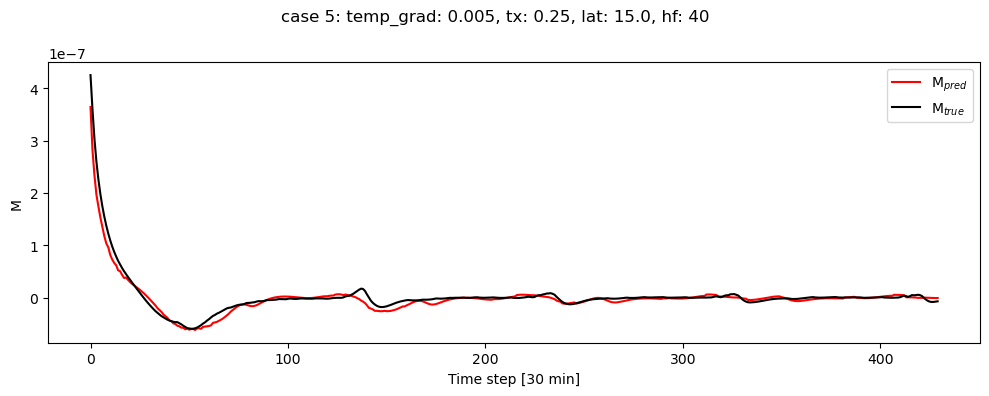

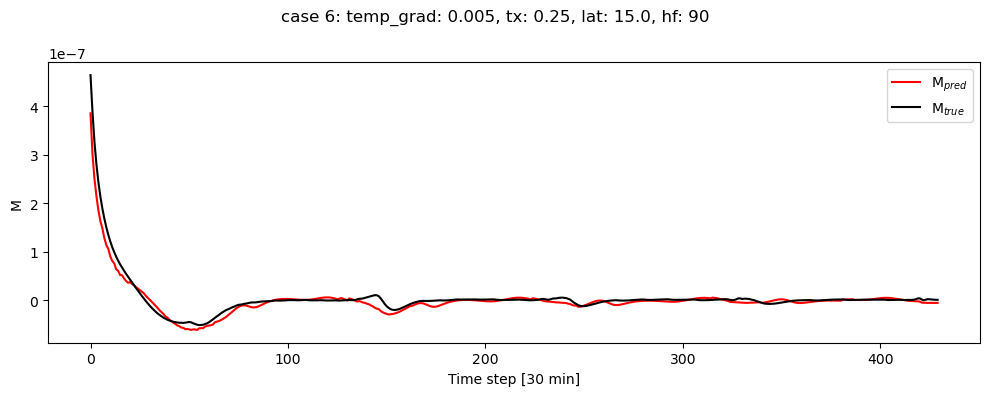

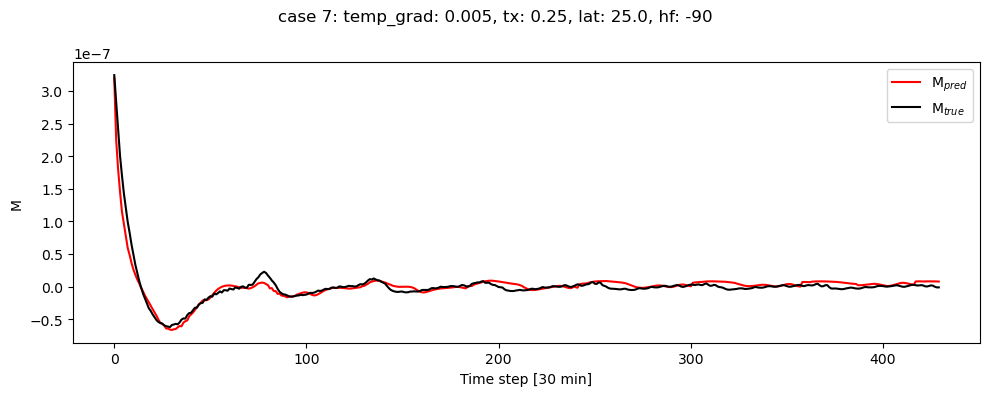

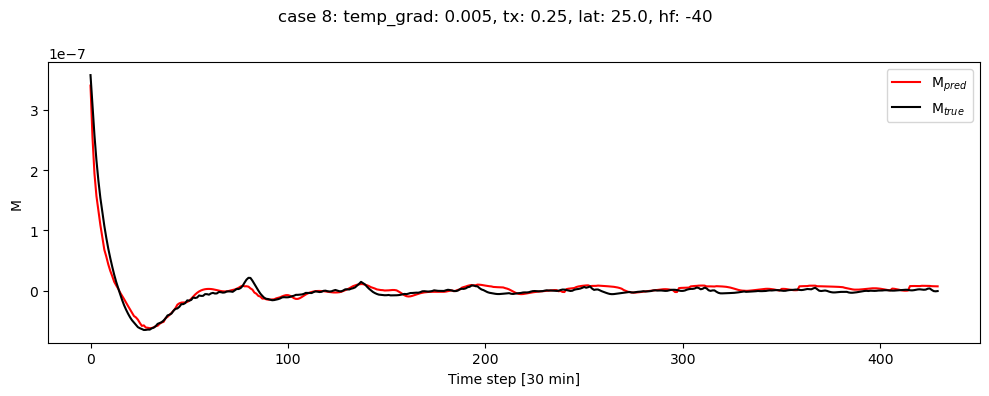

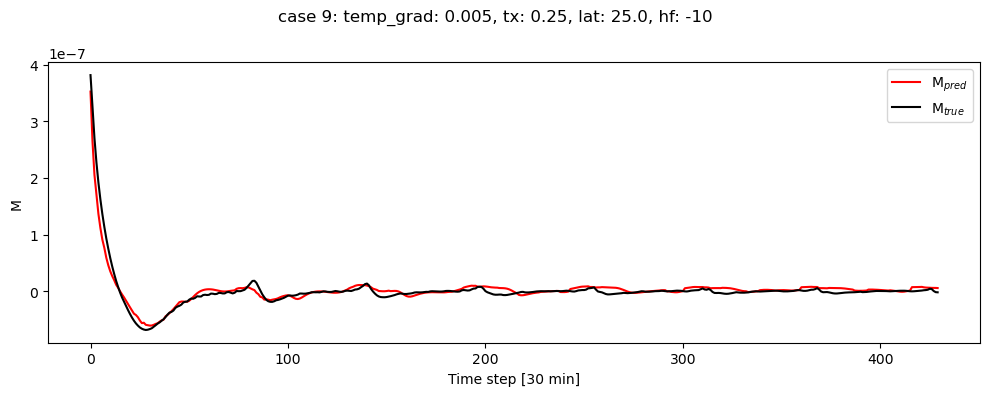

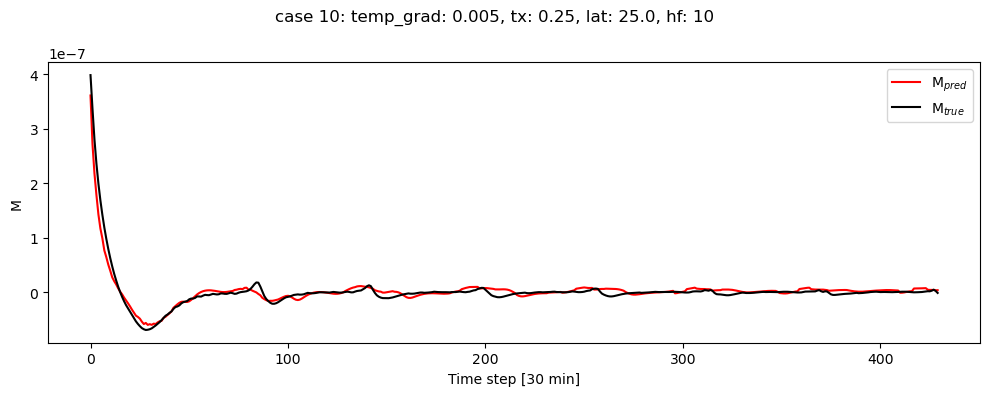

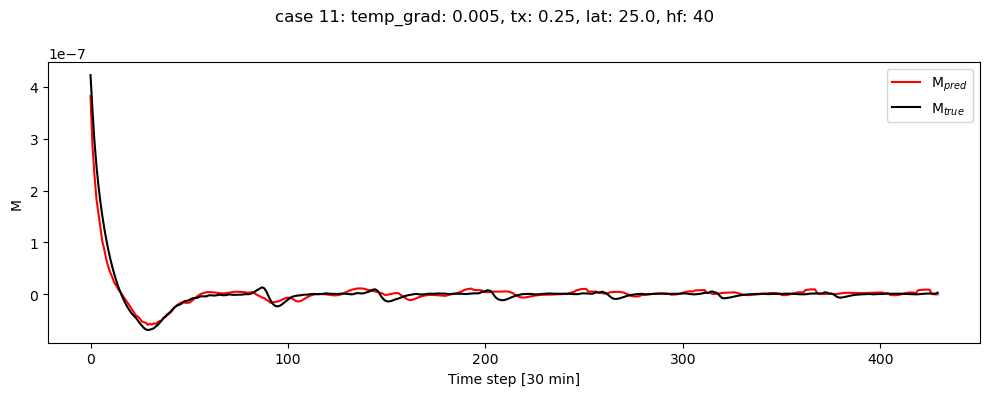

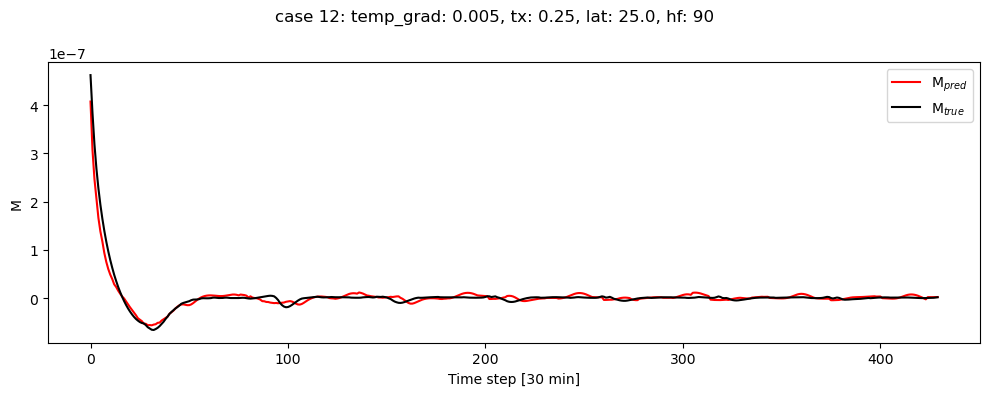

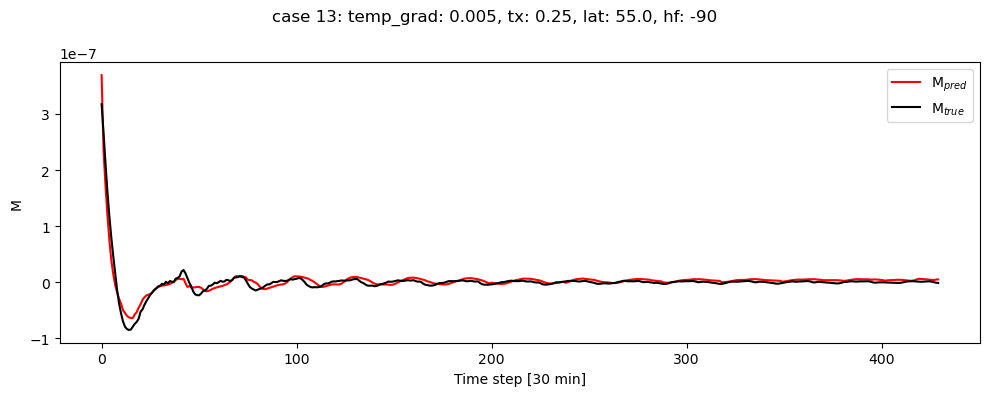

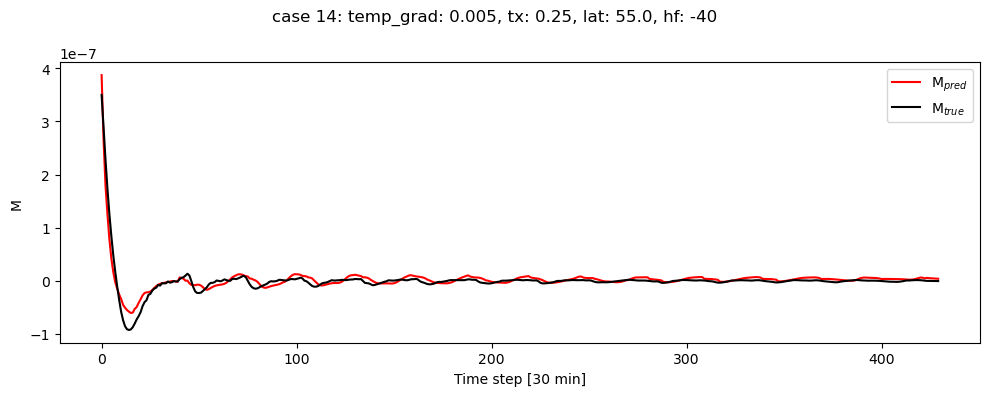

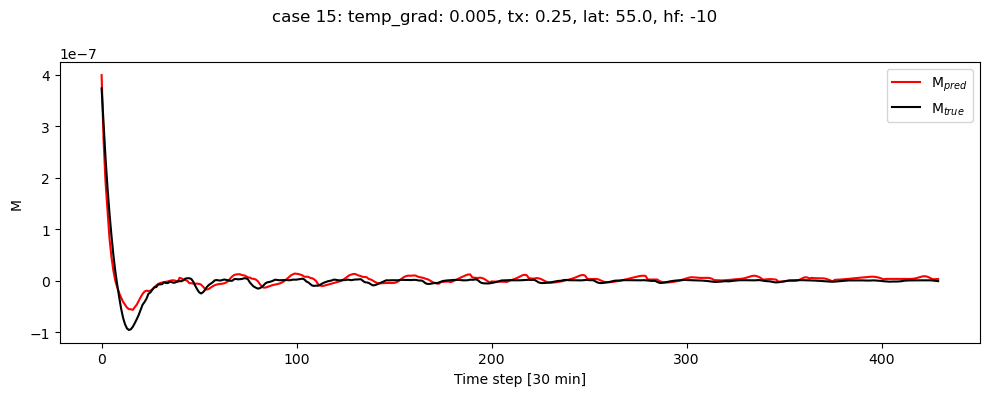

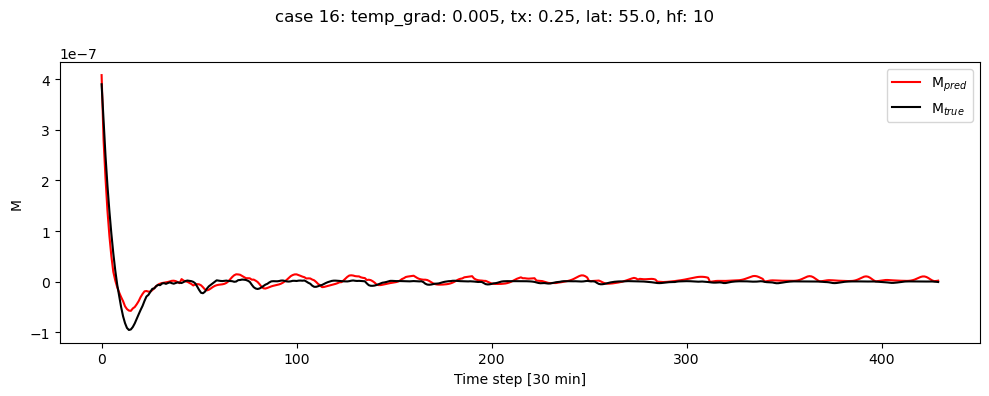

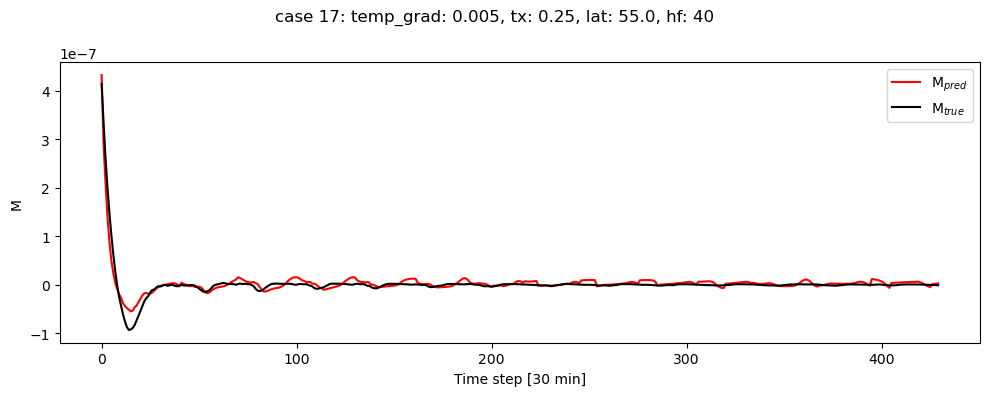

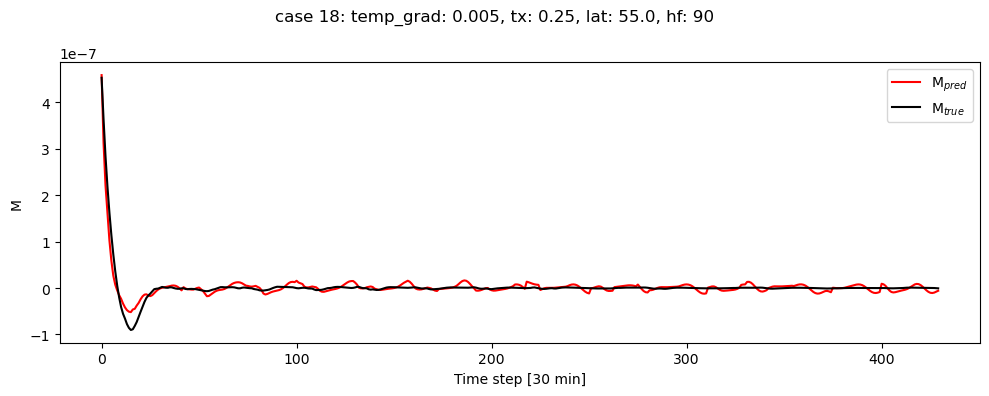

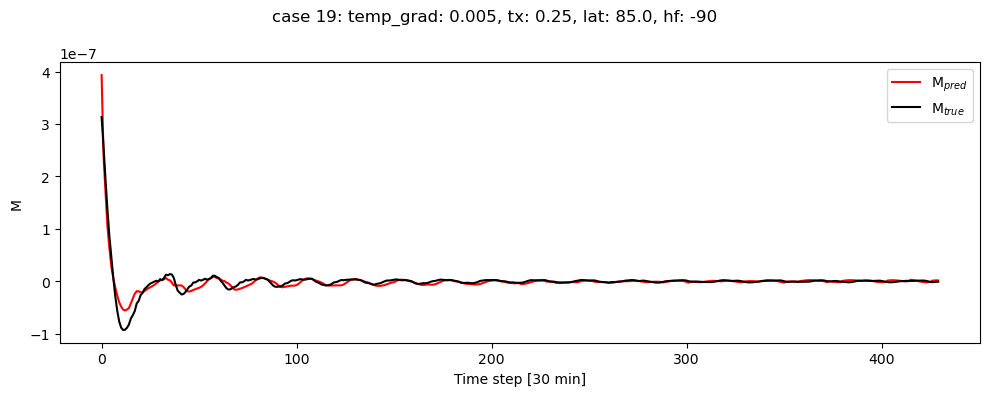

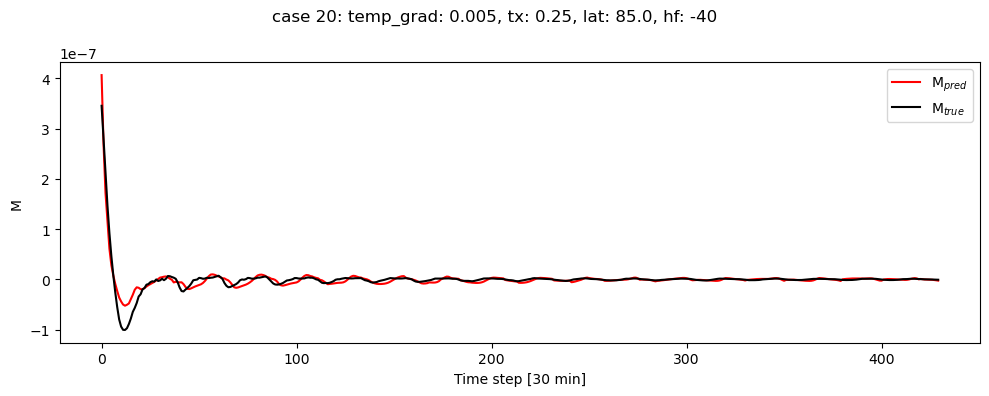

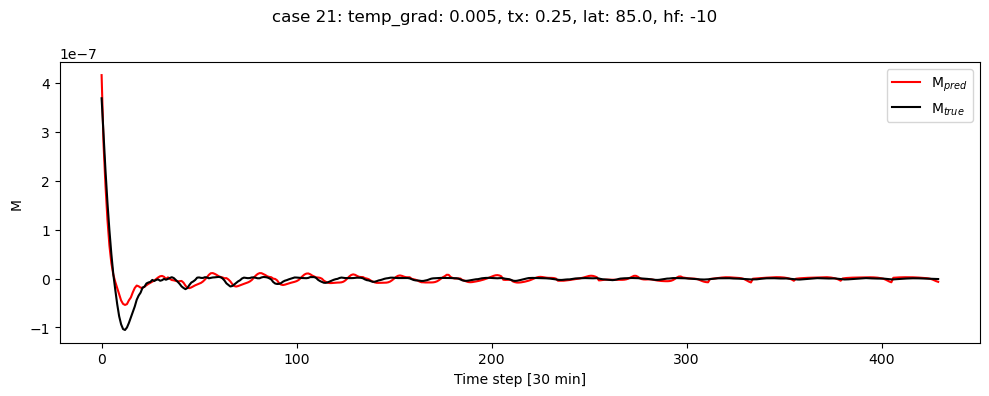

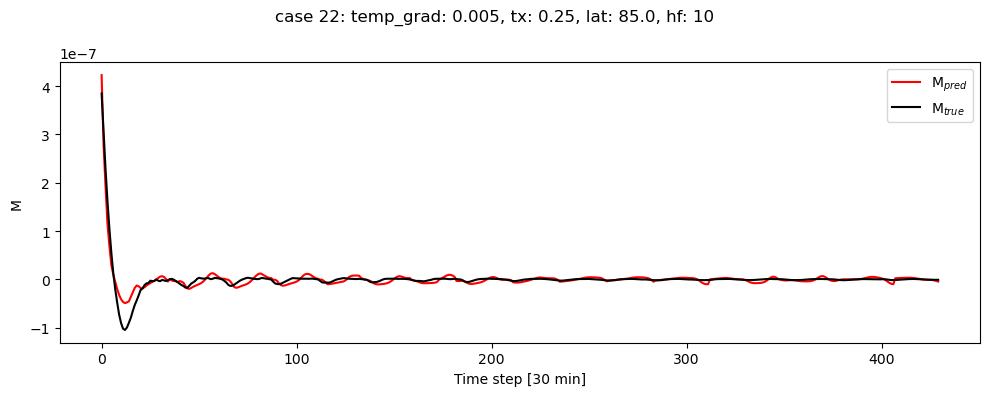

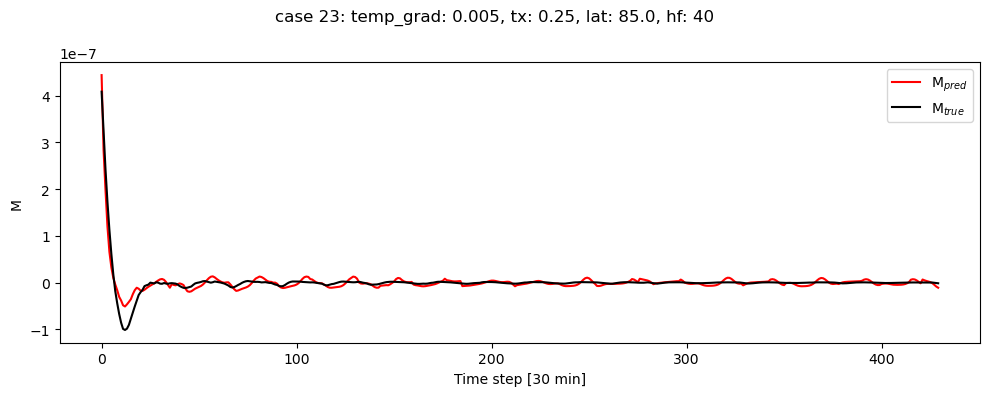

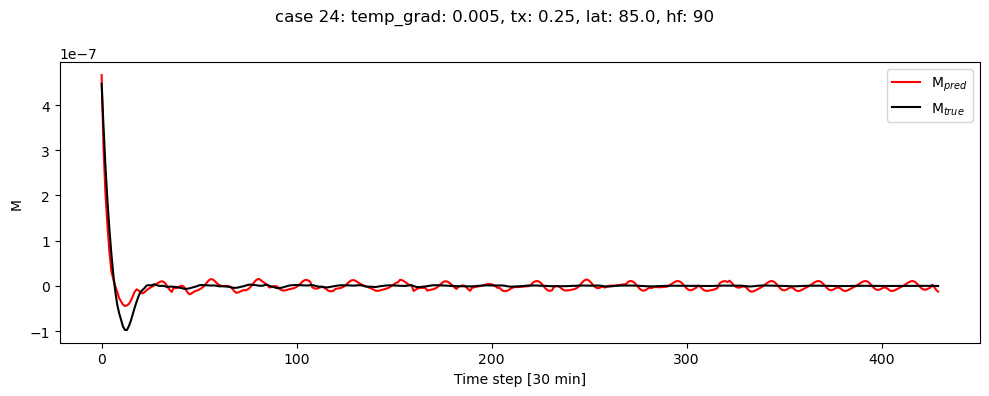

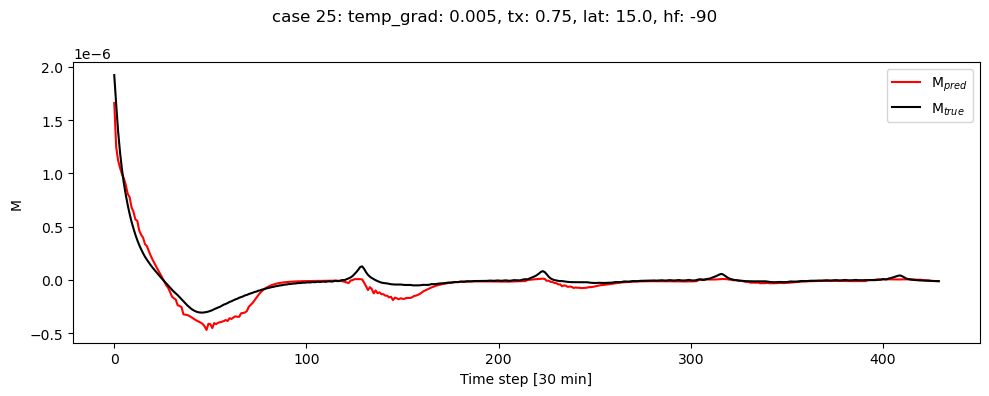

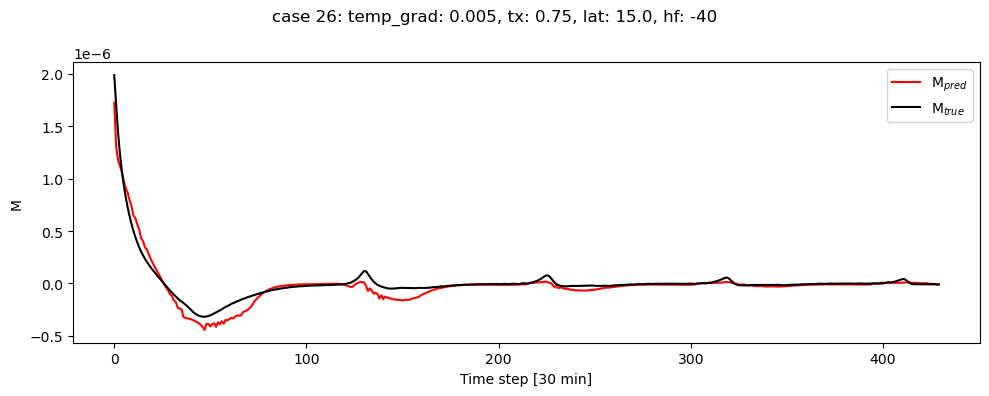

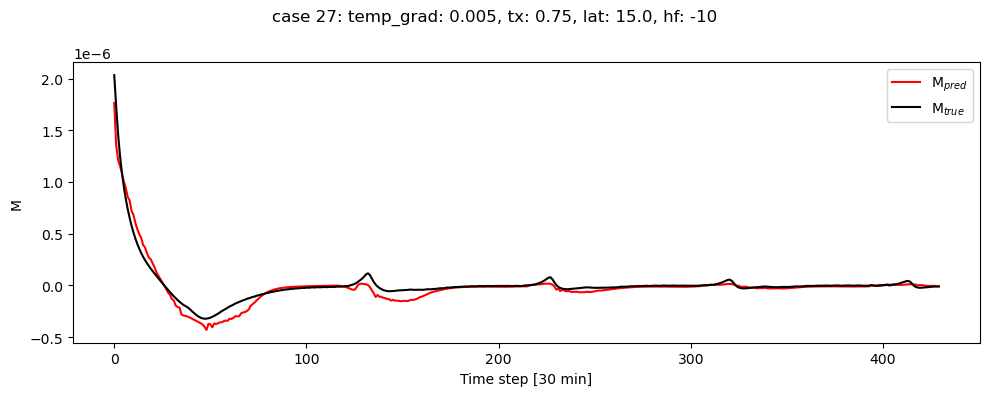

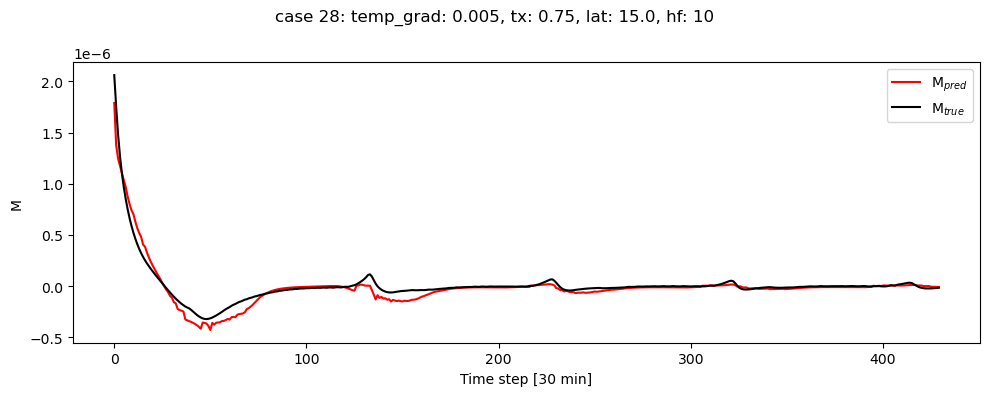

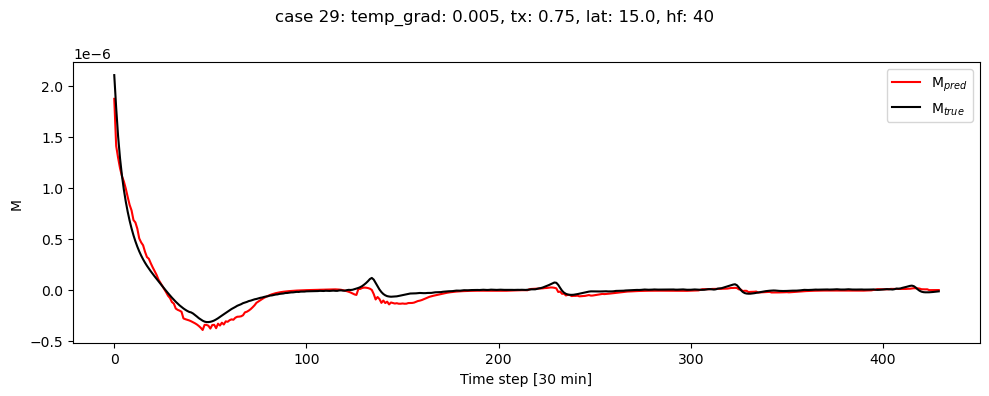

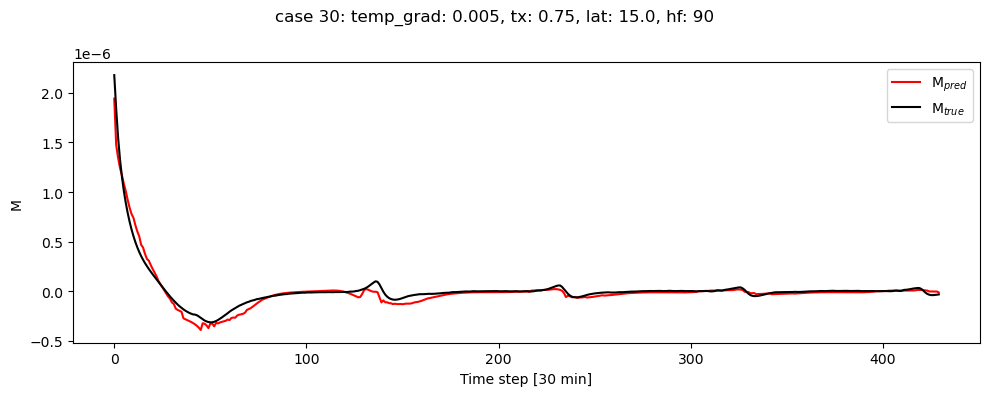

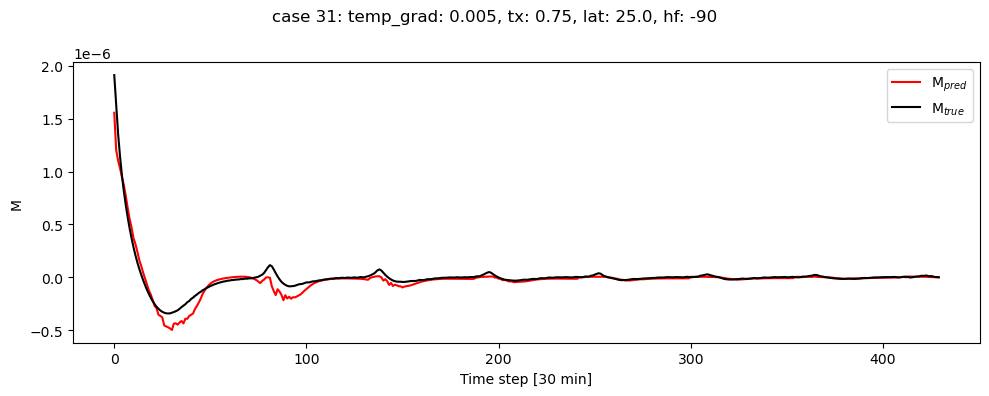

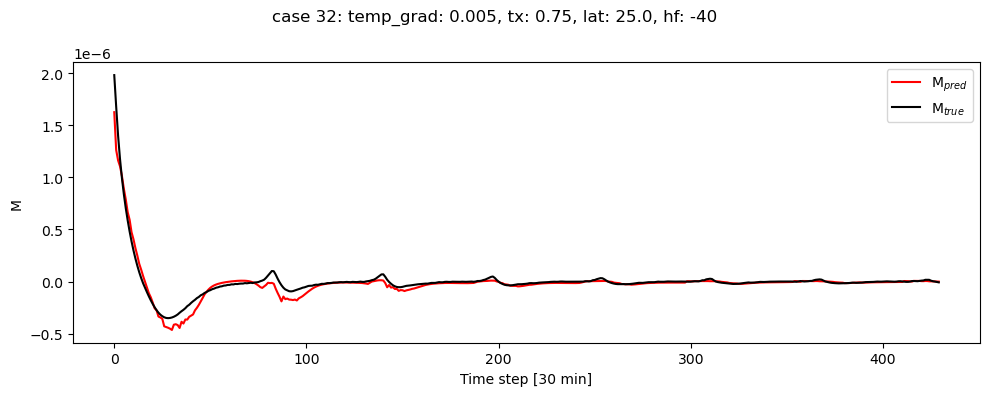

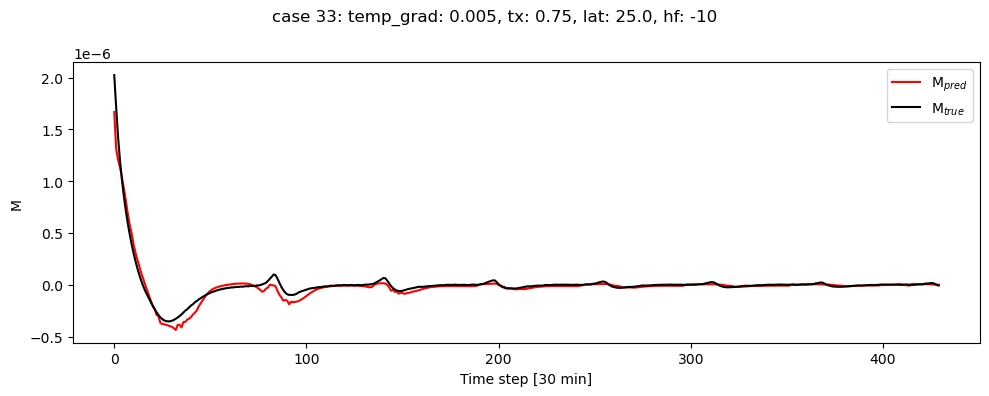

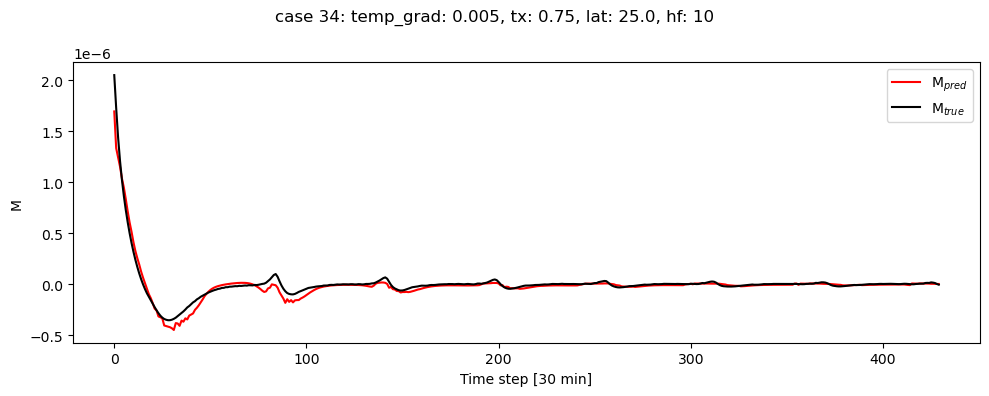

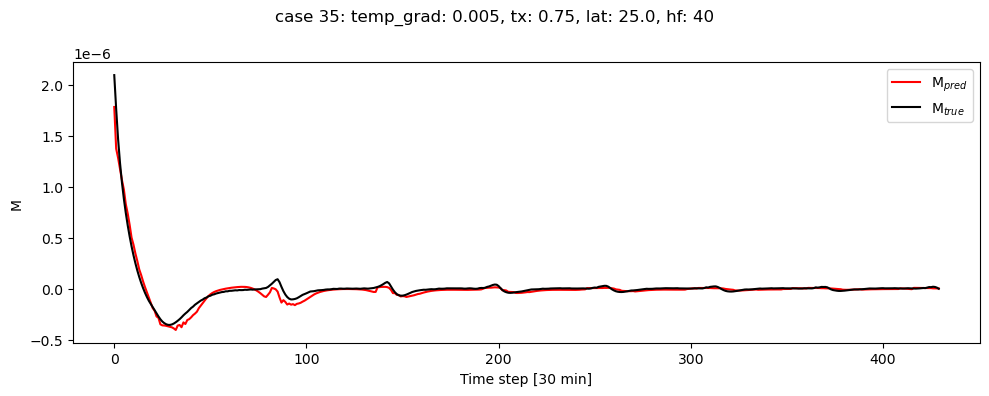

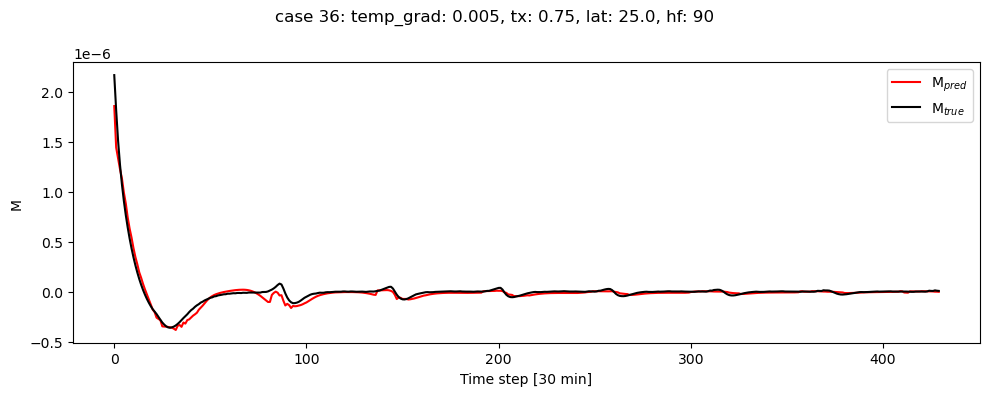

In [22]:
for i in range(0,36):
    case_specs = gotm_validation_case_dict[f"case_{i+1}"]
    tg, tx, lat, hf = case_specs['temp_grad'], case_specs['tx'], case_specs['lat'], case_specs['heat_flux']
    fig, ax = plt.subplots(1,1,figsize=(10,4),tight_layout=True,sharex=True)
    plt.suptitle(f"case {i+1}: temp_grad: {tg}, tx: {tx}, lat: {lat}, hf: {hf}")
    # ax.plot(10**X_val.detach().numpy()[config.n_time_steps*i:config.n_time_steps*(i+1),4], label="M$_{pres}$", color="blue")
    ax.plot(fcnn_prediction_val.detach().numpy()[config.n_time_steps*i:config.n_time_steps*(i+1)], label="M$_{pred}$", color="red")
    ax.plot(y_val[config.n_time_steps*i:config.n_time_steps*(i+1)], label="M$_{true}$", color="black")
    ax.set_xlabel("Time step [30 min]")
    ax.set_ylabel("M")
    ax.legend()

In [32]:
10**X_val[:,4]

tensor([3.6626e-08, 2.8778e-07, 6.1358e-07,  ..., 5.1924e-06, 5.1810e-06,
        5.1763e-06])

In [ ]:
plt.hist(y_val-10**X_val[:,4])

In [31]:
compute_rmse(10**X_val[:,4], y_val)

tensor(6.4425e-06)